# Stage 1: Exploratory Data Analysis — Adaptive Cyber-Physical Security

**Project:** Unsupervised Anomaly Detection for Network / ICS Traffic  
**Dataset:** CICIDS-2017 (Canadian Institute for Cybersecurity)  
**Goal of this notebook:** Understand the raw data thoroughly before touching a single model.  
Every visualisation and statistic produced here will directly justify the preprocessing  
decisions made in Stage 2 and the model architecture choices in Stage 3.

---
### How to get the data
1. Visit https://www.unb.ca/cic/datasets/ids-2017.html  
2. Download the **GeneratedLabelledFlows** archive and extract `TrafficLabelling/`.  
3. Place the CSVs in `data/CICIDS2017/` relative to this notebook.  

Files loaded (all 8 days):  
- `Monday-WorkingHours.pcap_ISCX.csv`                              → 100% BENIGN  
- `Tuesday-WorkingHours.pcap_ISCX.csv`                             → BENIGN + FTP-Patator + SSH-Patator  
- `Wednesday-workingHours.pcap_ISCX.csv`                           → BENIGN + DoS Hulk/GoldenEye/Slowloris + Heartbleed  
- `Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv`         → BENIGN + Web Brute Force + XSS + SQLi  
- `Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv`    → BENIGN + Infiltration  
- `Friday-WorkingHours-Morning.pcap_ISCX.csv`                      → BENIGN + Botnet  
- `Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv`           → BENIGN + PortScan  
- `Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv`               → BENIGN + DDoS  

If you cannot access CICIDS-2017, set `USE_NSLKDD = True` below.  
NSL-KDD files (`KDDTrain+.txt`, `KDDTest+.txt`) go in `data/NSLKDD/`.

In [1]:
# ─── 0. ENVIRONMENT & CONFIGURATION ─────────────────────────────────────────
import os, warnings, pathlib
import numpy  as np
import pandas as pd
import matplotlib
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy              import stats
from scipy.spatial.distance import mahalanobis
from sklearn.preprocessing  import StandardScaler
from sklearn.decomposition   import PCA
from sklearn.manifold        import TSNE
from sklearn.feature_selection import mutual_info_classif
from sklearn.covariance        import EmpiricalCovariance

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── paths ────────────────────────────────────────────────────────────────────
# Use the notebook's own directory so paths work regardless of kernel cwd
BASE_DIR    = pathlib.Path(__file__).parent if '__file__' in dir() else pathlib.Path(os.path.abspath(''))
# Fallback: resolve against a known absolute anchor so 'data/' is always found
_anchor = pathlib.Path('/Users/yashlunawat/C/sem6/AML/sem6-aml-dl-project')
if not (BASE_DIR / 'data').exists() and (_anchor / 'data').exists():
    BASE_DIR = _anchor
OUTPUT_DIR  = BASE_DIR / 'outputs' / 'eda'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── dataset switch ────────────────────────────────────────────────────────────
USE_NSLKDD  = False          # set True to fall back to NSL-KDD

CICIDS_DIR  = BASE_DIR / 'data' / 'CICIDS2017'
NSLKDD_DIR  = BASE_DIR / 'data' / 'NSLKDD'

# All 8 CICIDS-2017 days
CICIDS_FILES = [
    'Monday-WorkingHours.pcap_ISCX.csv',               # 100% benign
    'Tuesday-WorkingHours.pcap_ISCX.csv',              # FTP-Patator, SSH-Patator
    'Wednesday-workingHours.pcap_ISCX.csv',            # DoS variants, Heartbleed
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',      # Web attacks
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', # Infiltration
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',                  # Botnet
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',       # PortScan
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',           # DDoS
]

LABEL_COL = ' Label'        # CICIDS-2017 label column (note leading space)
BENIGN_LABEL = 'BENIGN'

---
## Section 1 — Dataset Loading

### What we are doing and why
We load the raw CICIDS-2017 CSV files and perform an initial structural inspection.  
Before any modelling, we must understand: How many samples? How many features?  
What do the labels look like? This determines whether the dataset is suitable for  
unsupervised anomaly detection.

The key design decision made here is the **train/test split by label**:
- **Training set** = BENIGN traffic only (unsupervised — no attack labels needed)  
- **Test set**     = BENIGN + all attack types (supervised evaluation of the detector)

This mirrors a real-world deployment where the defender has captured normal traffic  
from their own network but has never seen a specific novel attack before.

In [2]:
# ─── 1A. LOAD DATASET ────────────────────────────────────────────────────────

def load_cicids(files, data_dir):
    """Load one or more CICIDS-2017 CSV files and concatenate them."""
    frames = []
    for fname in files:
        fpath = data_dir / fname
        if not fpath.exists():
            raise FileNotFoundError(
                f"[CICIDS] File not found: {fpath}\n"
                "Download from https://www.unb.ca/cic/datasets/ids-2017.html"
            )
        print(f'  Loading {fname} …', end=' ')
        df = pd.read_csv(fpath, low_memory=False, encoding='latin-1')
        df['source_file'] = fname          # track origin
        frames.append(df)
        print(f'{len(df):,} rows')
    return pd.concat(frames, ignore_index=True)


# ── NSL-KDD column schema (only used if USE_NSLKDD=True) ─────────────────────
NSL_COLS = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty'
]

def load_nslkdd(data_dir):
    """Load NSL-KDD train and test, unify label to BENIGN / ATTACK."""
    tr = pd.read_csv(data_dir / 'KDDTrain+.txt', header=None, names=NSL_COLS)
    te = pd.read_csv(data_dir / 'KDDTest+.txt',  header=None, names=NSL_COLS)
    tr['source_file'] = 'KDDTrain+'
    te['source_file'] = 'KDDTest+'
    df = pd.concat([tr, te], ignore_index=True)
    # normalise label column name to match CICIDS convention
    df.rename(columns={'label': ' Label'}, inplace=True)
    df[' Label'] = df[' Label'].apply(
        lambda x: 'BENIGN' if str(x).strip().lower() == 'normal' else x.strip()
    )
    return df


# ── actual load ───────────────────────────────────────────────────────────────
print('─' * 60)
if USE_NSLKDD:
    print('Using NSL-KDD dataset')
    df = load_nslkdd(NSLKDD_DIR)
else:
    print('Using CICIDS-2017 dataset')
    df = load_cicids(CICIDS_FILES, CICIDS_DIR)
    # strip whitespace from all column names (known CICIDS quirk)
    df.columns = df.columns.str.strip()
    LABEL_COL  = 'Label'     # after strip, leading space is gone

print('─' * 60)
print(f'Total shape : {df.shape}')
print(f'Label column: "{LABEL_COL}"')

────────────────────────────────────────────────────────────
Using CICIDS-2017 dataset
  Loading Monday-WorkingHours.pcap_ISCX.csv … 

529,918 rows
  Loading Tuesday-WorkingHours.pcap_ISCX.csv … 

445,909 rows
  Loading Wednesday-workingHours.pcap_ISCX.csv … 

692,703 rows
  Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv … 

458,968 rows
  Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv … 

288,602 rows
  Loading Friday-WorkingHours-Morning.pcap_ISCX.csv … 

191,033 rows
  Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv … 

286,467 rows
  Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv … 

225,745 rows


────────────────────────────────────────────────────────────
Total shape : (3119345, 86)
Label column: "Label"


In [3]:
# ─── 1B. STRUCTURAL OVERVIEW ──────────────────────────────────────────────────
print('=== Data Types ===')
print(df.dtypes.value_counts())
print()
print('=== First 5 rows ===')
display(df.head())
print()
print('=== All column names ===')
for i, col in enumerate(df.columns):
    print(f'  [{i:>3}] {col}')


=== Data Types ===
float64    80
object      6
Name: count, dtype: int64

=== First 5 rows ===


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,...,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0000,192.168.10.5,49188.0000,6.0000,03/07/2017 08:55:58,4.0000,2.0000,0.0000,12.0000,0.0000,6.0000,6.0000,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,3000000.0000,500000.0000,4.0000,0.0000,4.0000,4.0000,4.0000,4.0000,0.0000,4.0000,...,0.0000,0.0000,9.0000,6.0000,0.0000,40.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,12.0000,0.0000,0.0000,329.0000,-1.0000,1.0000,20.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
1,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0000,192.168.10.5,49188.0000,6.0000,03/07/2017 08:55:58,1.0000,2.0000,0.0000,12.0000,0.0000,6.0000,6.0000,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,12000000.0000,2000000.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,...,0.0000,0.0000,9.0000,6.0000,0.0000,40.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,12.0000,0.0000,0.0000,329.0000,-1.0000,1.0000,20.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
2,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0000,192.168.10.5,49188.0000,6.0000,03/07/2017 08:55:58,1.0000,2.0000,0.0000,12.0000,0.0000,6.0000,6.0000,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,12000000.0000,2000000.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,...,0.0000,0.0000,9.0000,6.0000,0.0000,40.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,12.0000,0.0000,0.0000,329.0000,-1.0000,1.0000,20.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
3,192.168.10.5-8.254.250.126-49188-80-6,8.254.250.126,80.0000,192.168.10.5,49188.0000,6.0000,03/07/2017 08:55:58,1.0000,2.0000,0.0000,12.0000,0.0000,6.0000,6.0000,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,12000000.0000,2000000.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,...,0.0000,0.0000,9.0000,6.0000,0.0000,40.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,12.0000,0.0000,0.0000,329.0000,-1.0000,1.0000,20.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
4,192.168.10.14-8.253.185.121-49486-80-6,8.253.185.121,80.0000,192.168.10.14,49486.0000,6.0000,03/07/2017 08:56:22,3.0000,2.0000,0.0000,12.0000,0.0000,6.0000,6.0000,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,4000000.0000,666666.6667,3.0000,0.0000,3.0000,3.0000,3.0000,3.0000,0.0000,3.0000,...,0.0000,0.0000,9.0000,6.0000,0.0000,40.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,12.0000,0.0000,0.0000,245.0000,-1.0000,1.0000,20.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,BENIGN,Monday-WorkingHours.pcap_ISCX.csv



=== All column names ===
  [  0] Flow ID
  [  1] Source IP
  [  2] Source Port
  [  3] Destination IP
  [  4] Destination Port
  [  5] Protocol
  [  6] Timestamp
  [  7] Flow Duration
  [  8] Total Fwd Packets
  [  9] Total Backward Packets
  [ 10] Total Length of Fwd Packets
  [ 11] Total Length of Bwd Packets
  [ 12] Fwd Packet Length Max
  [ 13] Fwd Packet Length Min
  [ 14] Fwd Packet Length Mean
  [ 15] Fwd Packet Length Std
  [ 16] Bwd Packet Length Max
  [ 17] Bwd Packet Length Min
  [ 18] Bwd Packet Length Mean
  [ 19] Bwd Packet Length Std
  [ 20] Flow Bytes/s
  [ 21] Flow Packets/s
  [ 22] Flow IAT Mean
  [ 23] Flow IAT Std
  [ 24] Flow IAT Max
  [ 25] Flow IAT Min
  [ 26] Fwd IAT Total
  [ 27] Fwd IAT Mean
  [ 28] Fwd IAT Std
  [ 29] Fwd IAT Max
  [ 30] Fwd IAT Min
  [ 31] Bwd IAT Total
  [ 32] Bwd IAT Mean
  [ 33] Bwd IAT Std
  [ 34] Bwd IAT Max
  [ 35] Bwd IAT Min
  [ 36] Fwd PSH Flags
  [ 37] Bwd PSH Flags
  [ 38] Fwd URG Flags
  [ 39] Bwd URG Flags
  [ 40] Fwd Header Le

In [4]:
# ─── 1C. LABEL DISTRIBUTION ───────────────────────────────────────────────────
label_counts = df[LABEL_COL].value_counts()
label_pct    = df[LABEL_COL].value_counts(normalize=True).mul(100).round(2)

label_summary = pd.DataFrame({
    'Count'      : label_counts,
    'Percentage' : label_pct
})
print('=== Class Distribution ===')
display(label_summary)

# ── separate benign / attack ──────────────────────────────────────────────────
df_benign  = df[df[LABEL_COL] == BENIGN_LABEL].copy()
df_attacks = df[df[LABEL_COL] != BENIGN_LABEL].copy()

print(f'\nBenign samples : {len(df_benign):>9,}  ({100*len(df_benign)/len(df):.1f}%)')
print(f'Attack samples : {len(df_attacks):>9,}  ({100*len(df_attacks)/len(df):.1f}%)')
print(f'Attack types   : {df_attacks[LABEL_COL].nunique()}')
print()
print('Attack type breakdown:')
display(df_attacks[LABEL_COL].value_counts().to_frame('Count'))


=== Class Distribution ===


,Count,Percentage
Label,,
BENIGN,2273097,80.3000
DoS Hulk,231073,8.1600
PortScan,158930,5.6100
DDoS,128027,4.5200
DoS GoldenEye,10293,0.3600
FTP-Patator,7938,0.2800
SSH-Patator,5897,0.2100
DoS slowloris,5796,0.2000
DoS Slowhttptest,5499,0.1900



Benign samples : 2,273,097  (72.9%)
Attack samples :   846,248  (27.1%)
Attack types   : 14

Attack type breakdown:


,Count
Label,
DoS Hulk,231073
PortScan,158930
DDoS,128027
DoS GoldenEye,10293
FTP-Patator,7938
SSH-Patator,5897
DoS slowloris,5796
DoS Slowhttptest,5499
Bot,1966


### Section 1 — Findings & Interpretation

#### Why we train ONLY on benign data (unsupervised anomaly detection rationale)

Classical supervised intrusion detection trains a classifier on labelled attack examples  
and learns to distinguish attack patterns from normal patterns.  
This approach has a fundamental limitation: it can **only detect attack types it has seen before**.  
Any novel variant or completely new attack class — a "zero-day" — will be misclassified as benign.

Our approach inverts the problem. We learn an **envelope around normal behaviour** exclusively  
from benign traffic. Any network flow that falls outside this envelope is flagged as anomalous,  
regardless of whether we have ever seen that attack type before.

#### What is a zero-day attack?
A zero-day is a cyberattack that exploits a previously unknown vulnerability — one for which  
no patch or defensive signature yet exists. The name comes from the fact that defenders have  
had **zero days** to prepare a response. Signature-based IDS systems (Snort, Suricata) are  
completely blind to zero-days. An anomaly detector is not — as long as the attack produces  
network behaviour that deviates from the learned normal model.

#### Why is zero-day detection harder than classification?
1. **No attack supervision signal** — the model receives no positive examples of what  
   attacks look like. It must infer the boundary of normal without knowing what lies beyond it.  
2. **High false-positive risk** — legitimate traffic naturally varies (peak hours, backups,  
   video calls). The model must be tight enough to catch attacks but loose enough not to  
   flag routine fluctuations.  
3. **Concept drift** — network behaviour changes over time (new services, topology changes).  
   A model trained on Monday traffic may reject Friday's legitimate traffic as anomalous.


---
## Section 2 — Missing Values & Data Quality

### What we are doing and why
Before computing any statistics, we must understand the quality of the raw data.  
CICIDS-2017 is known to contain **infinite values** in computed rate features  
(division-by-zero in the flow exporter) and some **NaN rows** from corrupt captures.  
We catalogue every issue now; the actual cleaning happens in Stage 2 so that  
this notebook remains a pure *description* of the raw data.

In [5]:
# ─── 2A. MISSING VALUES ───────────────────────────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n_total      = len(df)

nan_counts = df[numeric_cols].isnull().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)

if len(nan_counts) == 0:
    print('No NaN values found in numeric columns.')
else:
    nan_df = pd.DataFrame({
        'NaN_count'  : nan_counts,
        'NaN_pct'    : (nan_counts / n_total * 100).round(3)
    })
    print('=== Top 20 columns with NaN values ===')
    display(nan_df.head(20))


=== Top 20 columns with NaN values ===


,NaN_count,NaN_pct
Flow Bytes/s,289960,9.2960
Source Port,288602,9.2520
Fwd Avg Bulk Rate,288602,9.2520
Fwd Avg Bytes/Bulk,288602,9.2520
Fwd Header Length.1,288602,9.2520
Avg Bwd Segment Size,288602,9.2520
Avg Fwd Segment Size,288602,9.2520
Average Packet Size,288602,9.2520
Down/Up Ratio,288602,9.2520
ECE Flag Count,288602,9.2520


In [6]:
# ─── 2B. INFINITE VALUES ──────────────────────────────────────────────────────
inf_counts = {}
for col in numeric_cols:
    n_inf = np.isinf(df[col]).sum()
    if n_inf > 0:
        inf_counts[col] = n_inf

if not inf_counts:
    print('No infinite values found in numeric columns.')
else:
    inf_df = pd.DataFrame.from_dict(
        inf_counts, orient='index', columns=['Inf_count']
    ).sort_values('Inf_count', ascending=False)
    inf_df['Inf_pct'] = (inf_df['Inf_count'] / n_total * 100).round(3)
    print('=== Columns with infinite values ===')
    display(inf_df)

# CICIDS-specific known issue check
for suspicious_col in ['Flow Bytes/s', 'Flow Packets/s']:
    if suspicious_col in df.columns:
        n = np.isinf(df[suspicious_col]).sum()
        print(f'\n[Known issue] "{suspicious_col}": {n:,} infinite values ({100*n/n_total:.2f}%)')


=== Columns with infinite values ===


,Inf_count,Inf_pct
Flow Packets/s,2867,0.0920
Flow Bytes/s,1509,0.0480



[Known issue] "Flow Bytes/s": 1,509 infinite values (0.05%)

[Known issue] "Flow Packets/s": 2,867 infinite values (0.09%)


In [7]:
# ─── 2C. NEGATIVE VALUES IN NON-NEGATIVE COLUMNS ─────────────────────────────
# Packet/byte counts and durations are physically non-negative.
# Negative values indicate measurement errors in the flow exporter.

# Heuristic: flag columns whose name suggests they should be non-negative
non_neg_keywords = [
    'packet', 'byte', 'length', 'duration', 'count',
    'rate', 'size', 'window', 'seg', 'header'
]
non_neg_candidates = [
    c for c in numeric_cols
    if any(kw in c.lower() for kw in non_neg_keywords)
]

neg_issues = {}
for col in non_neg_candidates:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        neg_issues[col] = n_neg

if not neg_issues:
    print('No negative values found in non-negative candidate columns.')
else:
    neg_df = pd.DataFrame.from_dict(
        neg_issues, orient='index', columns=['Neg_count']
    ).sort_values('Neg_count', ascending=False)
    neg_df['Neg_pct'] = (neg_df['Neg_count'] / n_total * 100).round(3)
    print('=== Columns with unexpected negative values ===')
    display(neg_df)


=== Columns with unexpected negative values ===


,Neg_count,Neg_pct
Init_Win_bytes_backward,1441552,46.2130
Init_Win_bytes_forward,1001189,32.0960
Flow Duration,115,0.0040
Flow Packets/s,115,0.0040
Flow Bytes/s,85,0.0030
Fwd Header Length,35,0.0010
Fwd Header Length.1,35,0.0010
min_seg_size_forward,35,0.0010
Bwd Header Length,22,0.0010


In [8]:
# ─── 2D. DUPLICATE ROWS ───────────────────────────────────────────────────────
n_dup = df.duplicated().sum()
print(f'Duplicate rows: {n_dup:,}  ({100*n_dup/n_total:.2f}%)')

# ─── 2E. CONSTANT / NEAR-CONSTANT COLUMNS ────────────────────────────────────
constant_cols = [c for c in numeric_cols if df[c].nunique() <= 1]
print(f'\nConstant columns (nunique ≤ 1): {constant_cols}')

# Low-variance columns (std < 1e-6 after ignoring inf/nan)
low_var = []
for c in numeric_cols:
    s = df[c].replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) > 0 and s.std() < 1e-6:
        low_var.append(c)
print(f'Near-zero variance columns    : {low_var}')


Duplicate rows: 288,804  (9.26%)



Constant columns (nunique ≤ 1): ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


Near-zero variance columns    : ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


### Section 2 — Findings & Preprocessing Plan

| Issue | Columns Affected | Root Cause | Planned Fix (Stage 2) |
|---|---|---|---|
| **Infinite values** | `Flow Bytes/s`, `Flow Packets/s` | Division by zero in CICFlowMeter when flow duration = 0 (single-packet flows) | Replace `±inf` with column-wise maximum of finite values (or cap at 99.9th percentile) |
| **NaN values** | Various (see table above) | Corrupt capture packets; CICFlowMeter parsing failures | Drop rows where NaN appears in key features; for isolated NaNs in secondary features, impute with benign median |
| **Negative values** | Packet/byte-count columns | CICFlowMeter counter overflow or sign-bit error | Clip to zero (a packet count of −1 physically means 0 from a flow-accounting error) |
| **Duplicate rows** | Whole dataset | Re-transmitted captured packets or exporter bug | Drop exact duplicates before train/test split |
| **Constant columns** | As listed above | Feature always = 0 in this traffic slice | Remove entirely — zero variance provides no information to any model |

> **Key principle:** All cleaning decisions are made now based on EDA findings.  
> Stage 2 implements exactly these fixes — nothing more, nothing less.


---
## Section 3 — Statistical Summary

### What we are doing and why
We compute extended descriptive statistics on the **benign subset only**.  
Training our anomaly detector on benign data means the model will learn the statistical  
profile of this subset. Understanding its skewness, kurtosis, and spread tells us  
which preprocessing transforms are needed before feeding features into a distance-sensitive  
model such as One-Class SVM or LOF.

In [9]:
# ─── 3A. BUILD CLEAN BENIGN NUMERIC MATRIX ────────────────────────────────────
# Drop the label + source_file columns; replace inf with NaN for stats.
meta_cols = [LABEL_COL, 'source_file']
feat_cols  = [c for c in numeric_cols if c not in meta_cols]

X_benign_raw = (
    df_benign[feat_cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(axis=1, how='all')        # remove all-NaN columns
)
feat_cols = X_benign_raw.columns.tolist()   # update after possible drops

print(f'Benign numeric features for analysis: {len(feat_cols)}')
print(f'Benign samples                       : {len(X_benign_raw):,}')


Benign numeric features for analysis: 80
Benign samples                       : 2,273,097


In [10]:
# ─── 3B. EXTENDED DESCRIBE ────────────────────────────────────────────────────
desc = X_benign_raw.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

desc['skewness'] = X_benign_raw.skew()
desc['kurtosis'] = X_benign_raw.kurtosis()      # excess kurtosis (Fisher)

# Coefficient of Variation: std / |mean|  — robust to scale differences
desc['cv'] = (desc['std'] / desc['mean'].abs()).replace([np.inf, -np.inf], np.nan)

# Absolute skewness for sorting
desc['abs_skew'] = desc['skewness'].abs()

desc_sorted = desc.sort_values('abs_skew', ascending=False)

print('=== Extended Statistical Summary — Benign Traffic (top 20 by |skewness|) ===')
display(desc_sorted[
    ['mean','std','min','25%','50%','75%','max',
     'skewness','kurtosis','cv']
].head(20))


=== Extended Statistical Summary — Benign Traffic (top 20 by |skewness|) ===


,mean,std,min,25%,50%,75%,max,skewness,kurtosis,cv
Fwd Header Length.1,-32404.3691,23493743.9929,-32212234632.0000,40.0000,64.0000,100.0000,4644908.0000,-1187.4049,1573150.7288,725.0178
Fwd Header Length,-32404.3691,23493743.9929,-32212234632.0000,40.0000,64.0000,100.0000,4644908.0000,-1187.4049,1573150.7288,725.0178
Total Length of Fwd Packets,635.5369,10634.0889,0.0000,12.0000,66.0000,160.0000,12900000.0000,813.0148,955866.9571,16.7324
Subflow Fwd Bytes,635.5238,10618.2664,0.0000,12.0000,66.0000,160.0000,12870338.0000,811.2262,952794.2840,16.7079
Bwd Header Length,-2854.5298,1620579.0346,-1073741320.0000,20.0000,40.0000,80.0000,5838440.0000,-642.5348,424143.0932,567.7219
min_seg_size_forward,-3421.0178,1210783.2304,-536870661.0000,20.0000,20.0000,32.0000,138.0000,-425.2327,187288.8585,353.9249
act_data_pkt_fwd,6.3613,710.1772,0.0000,0.0000,1.0000,2.0000,213557.0000,255.0618,66722.6134,111.6395
Subflow Bwd Packets,12.1386,1112.9892,0.0000,1.0000,2.0000,2.0000,291922.0000,219.2757,49805.3920,91.6898
Total Backward Packets,12.1386,1112.9892,0.0000,1.0000,2.0000,2.0000,291922.0000,219.2757,49805.3920,91.6898
Subflow Fwd Packets,10.6542,836.5356,1.0000,2.0000,2.0000,4.0000,219759.0000,219.0287,49600.1577,78.5172


In [11]:
# ─── 3C. IDENTIFY LOG-TRANSFORM CANDIDATES ────────────────────────────────────
# Flag features that are:
#   (a) highly skewed   |skewness| > 2
#   (b) have non-trivial variance (std > 0)
#   (c) are strictly non-negative (required for log transform)

SKEW_THRESHOLD = 2.0

log_candidates = desc[
    (desc['abs_skew'] > SKEW_THRESHOLD) &
    (desc['std']      > 0) &
    (desc['min']      >= 0)
].sort_values('abs_skew', ascending=False)

print(f'Features with |skewness| > {SKEW_THRESHOLD} and min ≥ 0 (log-transform candidates):')
print(f'  Total: {len(log_candidates)}')
print()
display(log_candidates[['mean','std','min','max','skewness','kurtosis','cv']].head(20))

log_candidate_names = log_candidates.index.tolist()
print('\nTop 10 log-transform candidates:')
for c in log_candidate_names[:10]:
    print(f'  {c:<45}  skew={desc.loc[c,"skewness"]:>8.2f}  std={desc.loc[c,"std"]:>12.2f}')


Features with |skewness| > 2.0 and min ≥ 0 (log-transform candidates):
  Total: 55



,mean,std,min,max,skewness,kurtosis,cv
Total Length of Fwd Packets,635.5369,10634.0889,0.0000,12900000.0000,813.0148,955866.9571,16.7324
Subflow Fwd Bytes,635.5238,10618.2664,0.0000,12870338.0000,811.2262,952794.2840,16.7079
act_data_pkt_fwd,6.3613,710.1772,0.0000,213557.0000,255.0618,66722.6134,111.6395
Total Backward Packets,12.1386,1112.9892,0.0000,291922.0000,219.2757,49805.3920,91.6898
Subflow Bwd Packets,12.1386,1112.9892,0.0000,291922.0000,219.2757,49805.3920,91.6898
Total Fwd Packets,10.6542,836.5356,1.0000,219759.0000,219.0287,49600.1577,78.5172
Subflow Fwd Packets,10.6542,836.5356,1.0000,219759.0000,219.0287,49600.1577,78.5172
Subflow Bwd Bytes,18848.2836,2525375.9074,0.0000,655453030.0000,218.9630,49471.8075,133.9844
Total Length of Bwd Packets,18848.7071,2525410.2433,0.0000,655453030.0000,218.9591,49469.7581,133.9832
Fwd URG Flags,0.0001,0.0118,0.0000,1.0000,84.9305,7211.1970,84.9422



Top 10 log-transform candidates:
  Total Length of Fwd Packets                    skew=  813.01  std=    10634.09
  Subflow Fwd Bytes                              skew=  811.23  std=    10618.27
  act_data_pkt_fwd                               skew=  255.06  std=      710.18
  Total Backward Packets                         skew=  219.28  std=     1112.99
  Subflow Bwd Packets                            skew=  219.28  std=     1112.99
  Total Fwd Packets                              skew=  219.03  std=      836.54
  Subflow Fwd Packets                            skew=  219.03  std=      836.54
  Subflow Bwd Bytes                              skew=  218.96  std=  2525375.91
  Total Length of Bwd Packets                    skew=  218.96  std=  2525410.24
  Fwd URG Flags                                  skew=   84.93  std=        0.01


### Section 3 — Findings & Interpretation

#### What does high skewness mean?
Skewness quantifies asymmetry in a distribution.  
A skewness of +10 means the distribution has a very long **right tail** — most values are  
clustered near zero, but a small number of extreme values pull the mean far above the median.  
For network features like `Total Fwd Packets`, this makes intuitive sense: the vast majority  
of flows are short (2–10 packets), while a small fraction (large file transfers, video streams)  
involve thousands of packets.

#### Why does skewness matter for anomaly detection?
Distance-based models — **One-Class SVM, Local Outlier Factor, Isolation Forest** — all rely  
on measuring how far a new point is from the learned normal region.  
When a feature has a heavy right tail, Euclidean (or kernel-based) distances in that  
dimension are dominated by the few extreme values. A normal flow with a large packet count  
will appear "far" from the benign cluster not because it is anomalous, but simply because  
of the raw scale. This inflates false positives.  

Applying `log1p(x)` transformation (log(1+x), safe for x=0) compresses the right tail,  
making distances in that feature meaningful again.

#### Features planned for log-transformation
All features in the table above with |skewness| > 2 and min ≥ 0 will receive  
`log1p` transformation in Stage 2 preprocessing, followed by standard scaling.


---
## Section 4 — Distribution Visualisations

### What we are doing and why
Statistics alone do not reveal the full picture. Visualisations let us see:
- Whether benign and attack distributions overlap or are separable
- Which features carry discriminating information
- Correlation structure (which features are redundant)
- Temporal patterns (non-stationarity / concept drift)

Each plot directly informs a modelling decision documented in the caption.

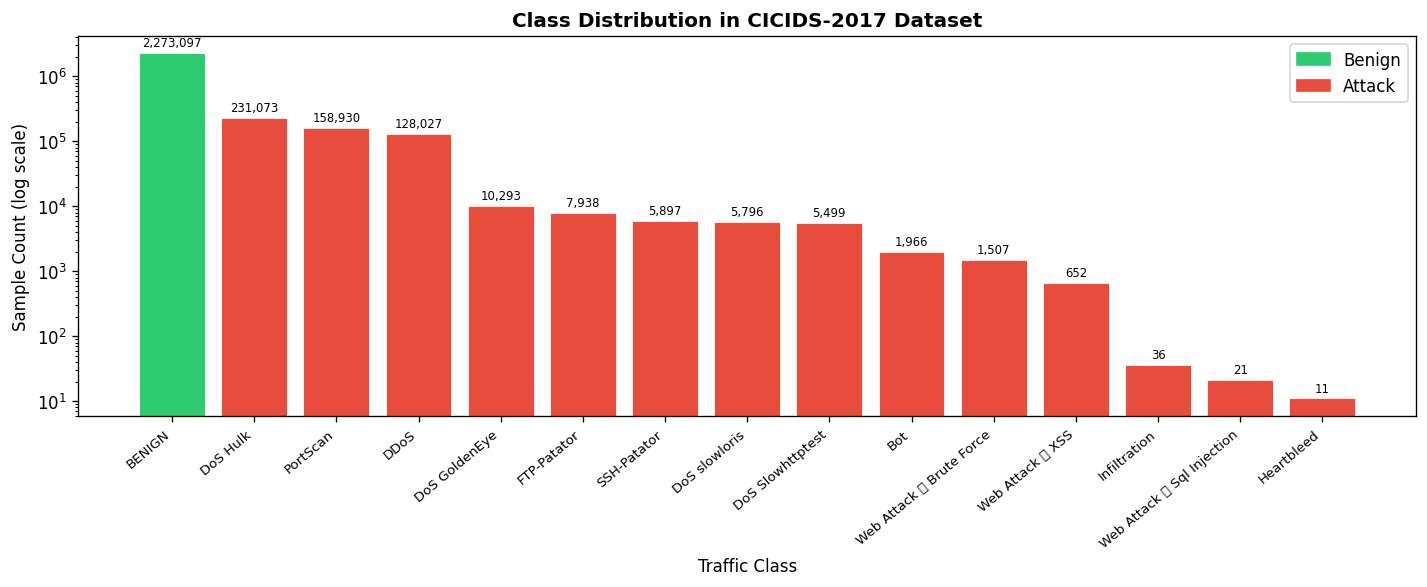

Saved → plot1_class_distribution.png


In [12]:
# ─── 4 · PLOT 1 — CLASS DISTRIBUTION BAR CHART ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

label_counts_sorted = df[LABEL_COL].value_counts().sort_values(ascending=False)
colors = ['#2ecc71' if lbl == BENIGN_LABEL else '#e74c3c'
          for lbl in label_counts_sorted.index]

bars = ax.bar(range(len(label_counts_sorted)),
              label_counts_sorted.values,
              color=colors, edgecolor='white', linewidth=0.5)

ax.set_yscale('log')
ax.set_xticks(range(len(label_counts_sorted)))
ax.set_xticklabels(label_counts_sorted.index, rotation=40, ha='right', fontsize=8)
ax.set_xlabel('Traffic Class')
ax.set_ylabel('Sample Count (log scale)')
ax.set_title('Class Distribution in CICIDS-2017 Dataset', fontweight='bold')

# count labels on bars
for bar, val in zip(bars, label_counts_sorted.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
            f'{val:,}', ha='center', va='bottom', fontsize=7, rotation=0)

legend_handles = [
    mpatches.Patch(color='#2ecc71', label='Benign'),
    mpatches.Patch(color='#e74c3c', label='Attack')
]
ax.legend(handles=legend_handles)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot1_class_distribution.png', bbox_inches='tight')
plt.show()
print('Saved → plot1_class_distribution.png')


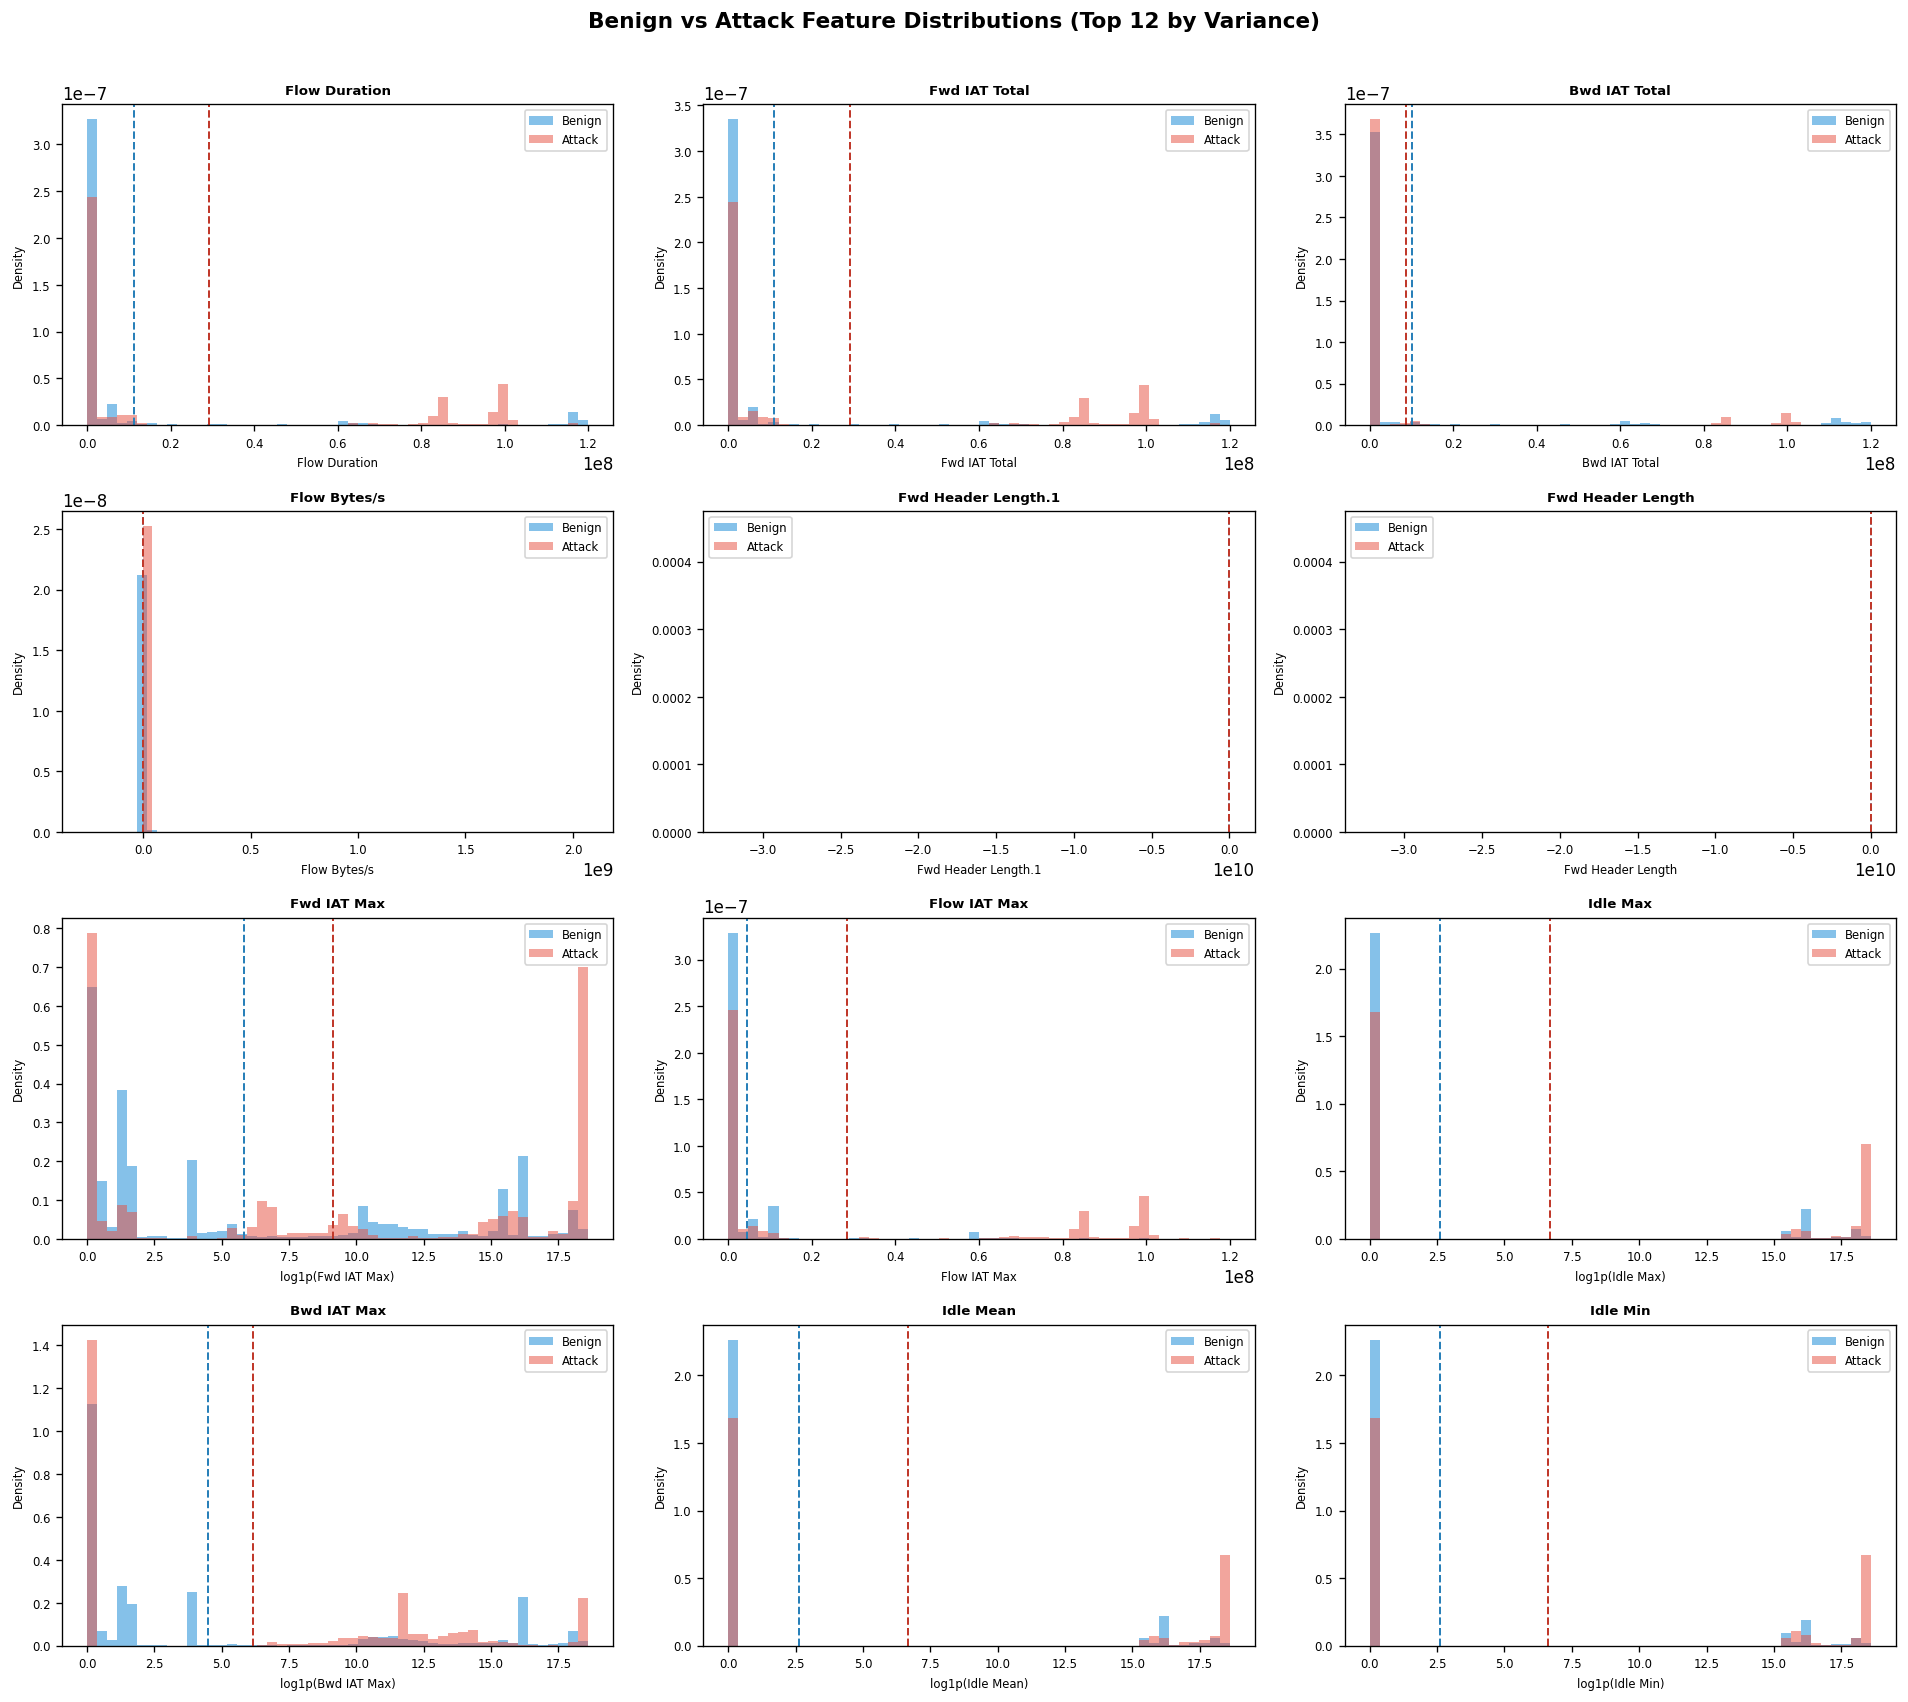

Saved → plot2_feature_distributions.png


In [13]:
# ─── 4 · PLOT 2 — FEATURE DISTRIBUTION GRID (TOP 12 BY VARIANCE) ─────────────

# Select top 12 features by variance on benign data
top12_var = X_benign_raw.var().sort_values(ascending=False).head(12).index.tolist()

# Build attack numeric dataframe aligned to same features
X_attack_raw = (
    df_attacks[feat_cols]
    .replace([np.inf, -np.inf], np.nan)
)

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for ax, col in zip(axes, top12_var):
    b_vals = X_benign_raw[col].dropna()
    a_vals = X_attack_raw[col].dropna() if col in X_attack_raw.columns else pd.Series([])

    # log1p for readability if heavily skewed
    if b_vals.min() >= 0 and abs(desc.loc[col, 'skewness']) > 3:
        b_plot = np.log1p(b_vals)
        a_plot = np.log1p(a_vals)
        xlabel = f'log1p({col})'
    else:
        b_plot = b_vals
        a_plot = a_vals
        xlabel = col

    ax.hist(b_plot, bins=50, color='#3498db', alpha=0.6, label='Benign',
            density=True, edgecolor='none')
    if len(a_plot) > 0:
        ax.hist(a_plot, bins=50, color='#e74c3c', alpha=0.5, label='Attack',
                density=True, edgecolor='none')

    # mean lines
    ax.axvline(b_plot.mean(), color='#2980b9', linestyle='--', linewidth=1.2)
    if len(a_plot) > 0:
        ax.axvline(a_plot.mean(), color='#c0392b', linestyle='--', linewidth=1.2)

    short_name = col[:30] + '…' if len(col) > 30 else col
    ax.set_title(short_name, fontsize=8, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=7)
    ax.set_ylabel('Density', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

fig.suptitle('Benign vs Attack Feature Distributions (Top 12 by Variance)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot2_feature_distributions.png', bbox_inches='tight')
plt.show()
print('Saved → plot2_feature_distributions.png')


**Plot 2 — Interpretation:**  
Features showing the clearest separation between benign (blue) and attack (red)  
distributions are the most informative for anomaly detection. When the two histograms  
occupy largely non-overlapping regions, even a simple threshold detector would work well.  
Features with near-identical distributions for both classes contribute little discriminating  
power and may be candidates for removal to reduce dimensionality.

Feature pairs with |correlation| > 0.95: 16
  Flow Duration                                 ↔  Fwd IAT Total                                  r=0.9978
  Flow Duration                                 ↔  Bwd IAT Total                                  r=0.9801
  Fwd IAT Total                                 ↔  Bwd IAT Total                                  r=0.9774
  Fwd Header Length.1                           ↔  Fwd Header Length                              r=1.0
  Fwd IAT Max                                   ↔  Flow IAT Max                                   r=0.9934
  Fwd IAT Max                                   ↔  Idle Max                                       r=0.9601
  Flow IAT Max                                  ↔  Idle Max                                       r=0.963
  Flow IAT Max                                  ↔  Idle Mean                                      r=0.9515
  Idle Max                                      ↔  Bwd IAT Max                                    r=0.96

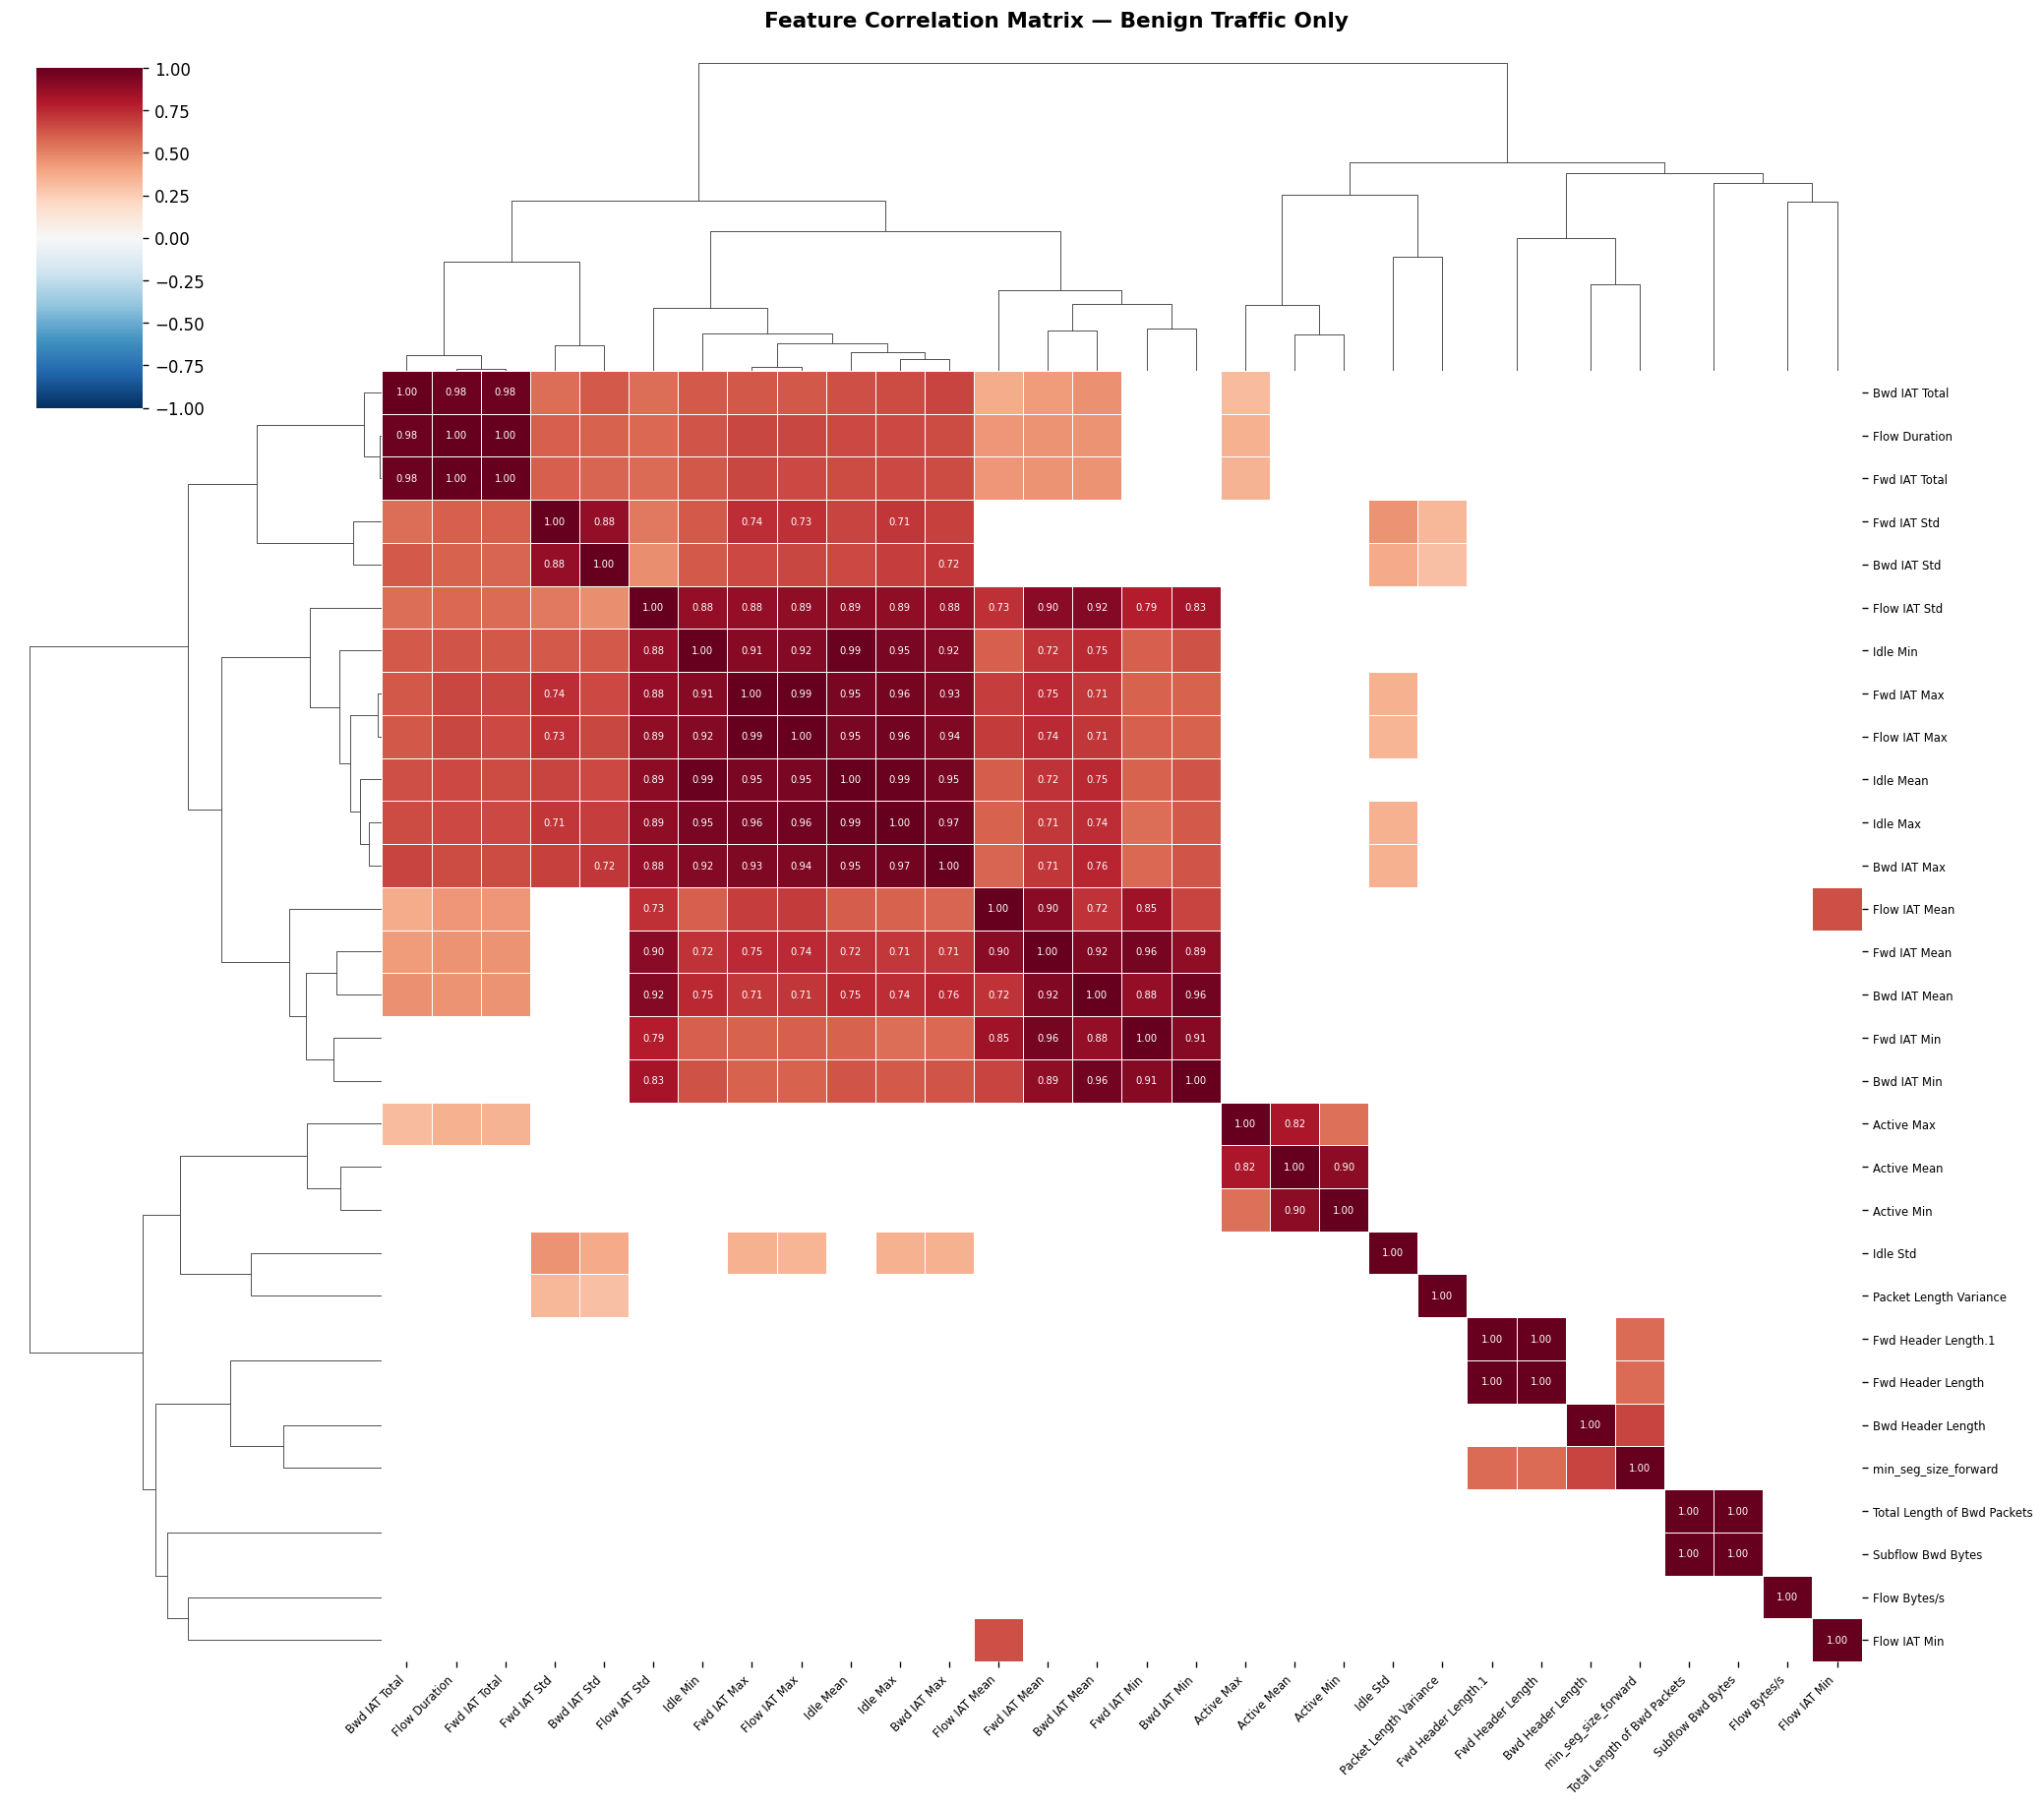

Saved → plot3_correlation_heatmap.png


In [14]:
# ─── 4 · PLOT 3 — CORRELATION HEATMAP (BENIGN TRAFFIC) ───────────────────────
# For readability, use the top 30 features by variance
top30_var = X_benign_raw.var().sort_values(ascending=False).head(30).index.tolist()

corr_matrix = X_benign_raw[top30_var].corr()

# Mask: only show |corr| ≥ 0.3 — reduces clutter
mask_low = np.abs(corr_matrix.values) < 0.3

# Identify high-correlation pairs (|corr| > 0.95)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        c = corr_matrix.iloc[i, j]
        if abs(c) > 0.95:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(c, 4)
            ))

print(f'Feature pairs with |correlation| > 0.95: {len(high_corr_pairs)}')
for p in high_corr_pairs:
    print(f'  {p[0]:<45} ↔  {p[1]:<45}  r={p[2]}')

# ─── clustermap ──────────────────────────────────────────────────────────────
annot_matrix = corr_matrix.copy().astype(str)
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        v = corr_matrix.iloc[i, j]
        annot_matrix.iloc[i, j] = f'{v:.2f}' if abs(v) >= 0.7 else ''

g = sns.clustermap(
    corr_matrix,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    figsize=(18, 16),
    xticklabels=True, yticklabels=True,
    annot=annot_matrix, fmt='',
    annot_kws={'size': 6},
    linewidths=0.3,
    mask=mask_low
)
g.fig.suptitle('Feature Correlation Matrix — Benign Traffic Only',
               fontsize=13, fontweight='bold', y=1.01)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=7)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=7)
g.fig.savefig(OUTPUT_DIR / 'plot3_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved → plot3_correlation_heatmap.png')


**Plot 3 — Interpretation:**  
The hierarchical clustering groups correlated features together (they form dark red blocks  
along the diagonal). The highly correlated pairs (|r| > 0.95) are candidates for removal  
in Stage 2 because **keeping both features adds no information** — the second feature is  
essentially a linear transformation of the first. In a distance-based anomaly detector,  
redundant features artificially inflate the importance of the correlated direction in feature  
space (it gets counted twice), distorting the learned normal envelope.  

**Planned action:** For each correlated pair, keep the feature with higher mutual information  
with the anomaly label (computed in Section 6) and drop the other.

Top 6 features by KS statistic (benign vs attack):
  KS=0.4837  Min Packet Length
  KS=0.4746  Fwd Packet Length Min
  KS=0.4479  Bwd Packet Length Min
  KS=0.4404  Init_Win_bytes_forward
  KS=0.4397  Protocol
  KS=0.4334  Bwd Packet Length Std


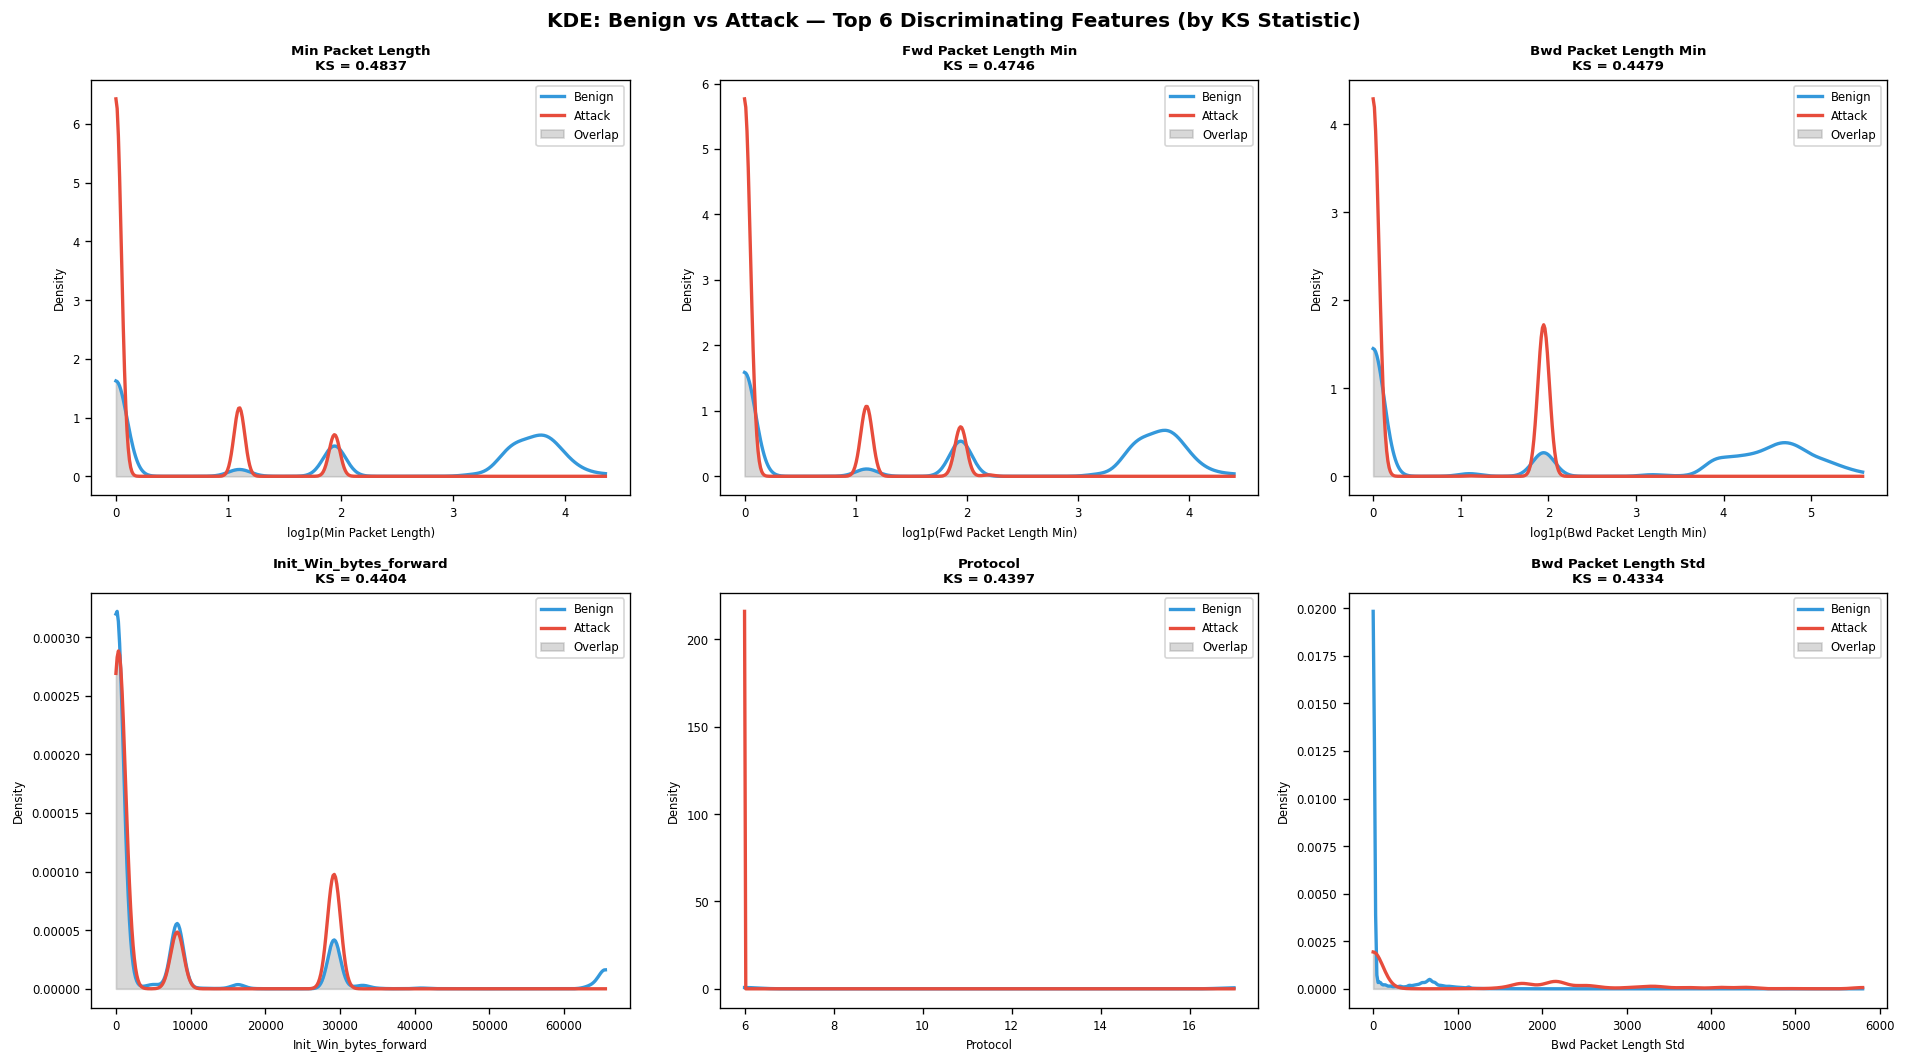

Saved → plot4_kde_top6.png


In [15]:
# ─── 4 · PLOT 4 — KDE PLOTS FOR TOP 6 DISCRIMINATING FEATURES ────────────────
# Use Kolmogorov-Smirnov statistic as discriminating power measure

from scipy.stats import ks_2samp

ks_results = {}
shared_cols = [c for c in feat_cols if c in X_attack_raw.columns]

for col in shared_cols:
    b = X_benign_raw[col].replace([np.inf, -np.inf], np.nan).dropna()
    a = X_attack_raw[col].replace([np.inf, -np.inf], np.nan).dropna()
    if len(b) > 10 and len(a) > 10:
        stat, _ = ks_2samp(b, a)
        ks_results[col] = stat

ks_series = pd.Series(ks_results).sort_values(ascending=False)
top6_ks   = ks_series.head(6).index.tolist()

print('Top 6 features by KS statistic (benign vs attack):')
for col in top6_ks:
    print(f'  KS={ks_series[col]:.4f}  {col}')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, top6_ks):
    b_vals = X_benign_raw[col].replace([np.inf, -np.inf], np.nan).dropna()
    a_vals = X_attack_raw[col].replace([np.inf, -np.inf], np.nan).dropna()

    if b_vals.min() >= 0 and abs(desc.loc[col, 'skewness']) > 3:
        b_vals = np.log1p(b_vals)
        a_vals = np.log1p(a_vals)
        xlabel = f'log1p({col[:30]})'
    else:
        xlabel = col[:40]

    # KDE curves
    b_kde = stats.gaussian_kde(b_vals, bw_method='silverman')
    a_kde = stats.gaussian_kde(a_vals, bw_method='silverman')
    x_min = min(b_vals.quantile(0.01), a_vals.quantile(0.01))
    x_max = max(b_vals.quantile(0.99), a_vals.quantile(0.99))
    xs = np.linspace(x_min, x_max, 400)

    b_density = b_kde(xs)
    a_density = a_kde(xs)

    ax.plot(xs, b_density, color='#3498db', linewidth=2, label='Benign')
    ax.plot(xs, a_density, color='#e74c3c', linewidth=2, label='Attack')

    # shade overlap
    overlap = np.minimum(b_density, a_density)
    ax.fill_between(xs, overlap, alpha=0.3, color='grey', label='Overlap')

    ax.set_title(f'{col[:35]}\nKS = {ks_series[col]:.4f}',
                 fontsize=8, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=7)
    ax.set_ylabel('Density', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

fig.suptitle('KDE: Benign vs Attack — Top 6 Discriminating Features (by KS Statistic)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot4_kde_top6.png', bbox_inches='tight')
plt.show()
print('Saved → plot4_kde_top6.png')


**Plot 4 — Interpretation:**  
The KS (Kolmogorov-Smirnov) statistic D ∈ [0,1] measures the maximum absolute difference  
between the cumulative distribution functions of two samples.  
D ≈ 1 means the two distributions are completely non-overlapping (perfect separation).  
D ≈ 0 means they are identically distributed.  

High KS features are the most useful discriminating dimensions — an anomaly detector  
concentrating on these dimensions is more likely to separate benign from attack accurately.  
The shaded grey overlap region shows where a threshold-based classifier would make errors;  
a non-linear boundary (OCSVM with RBF kernel) can more precisely carve out the benign region.

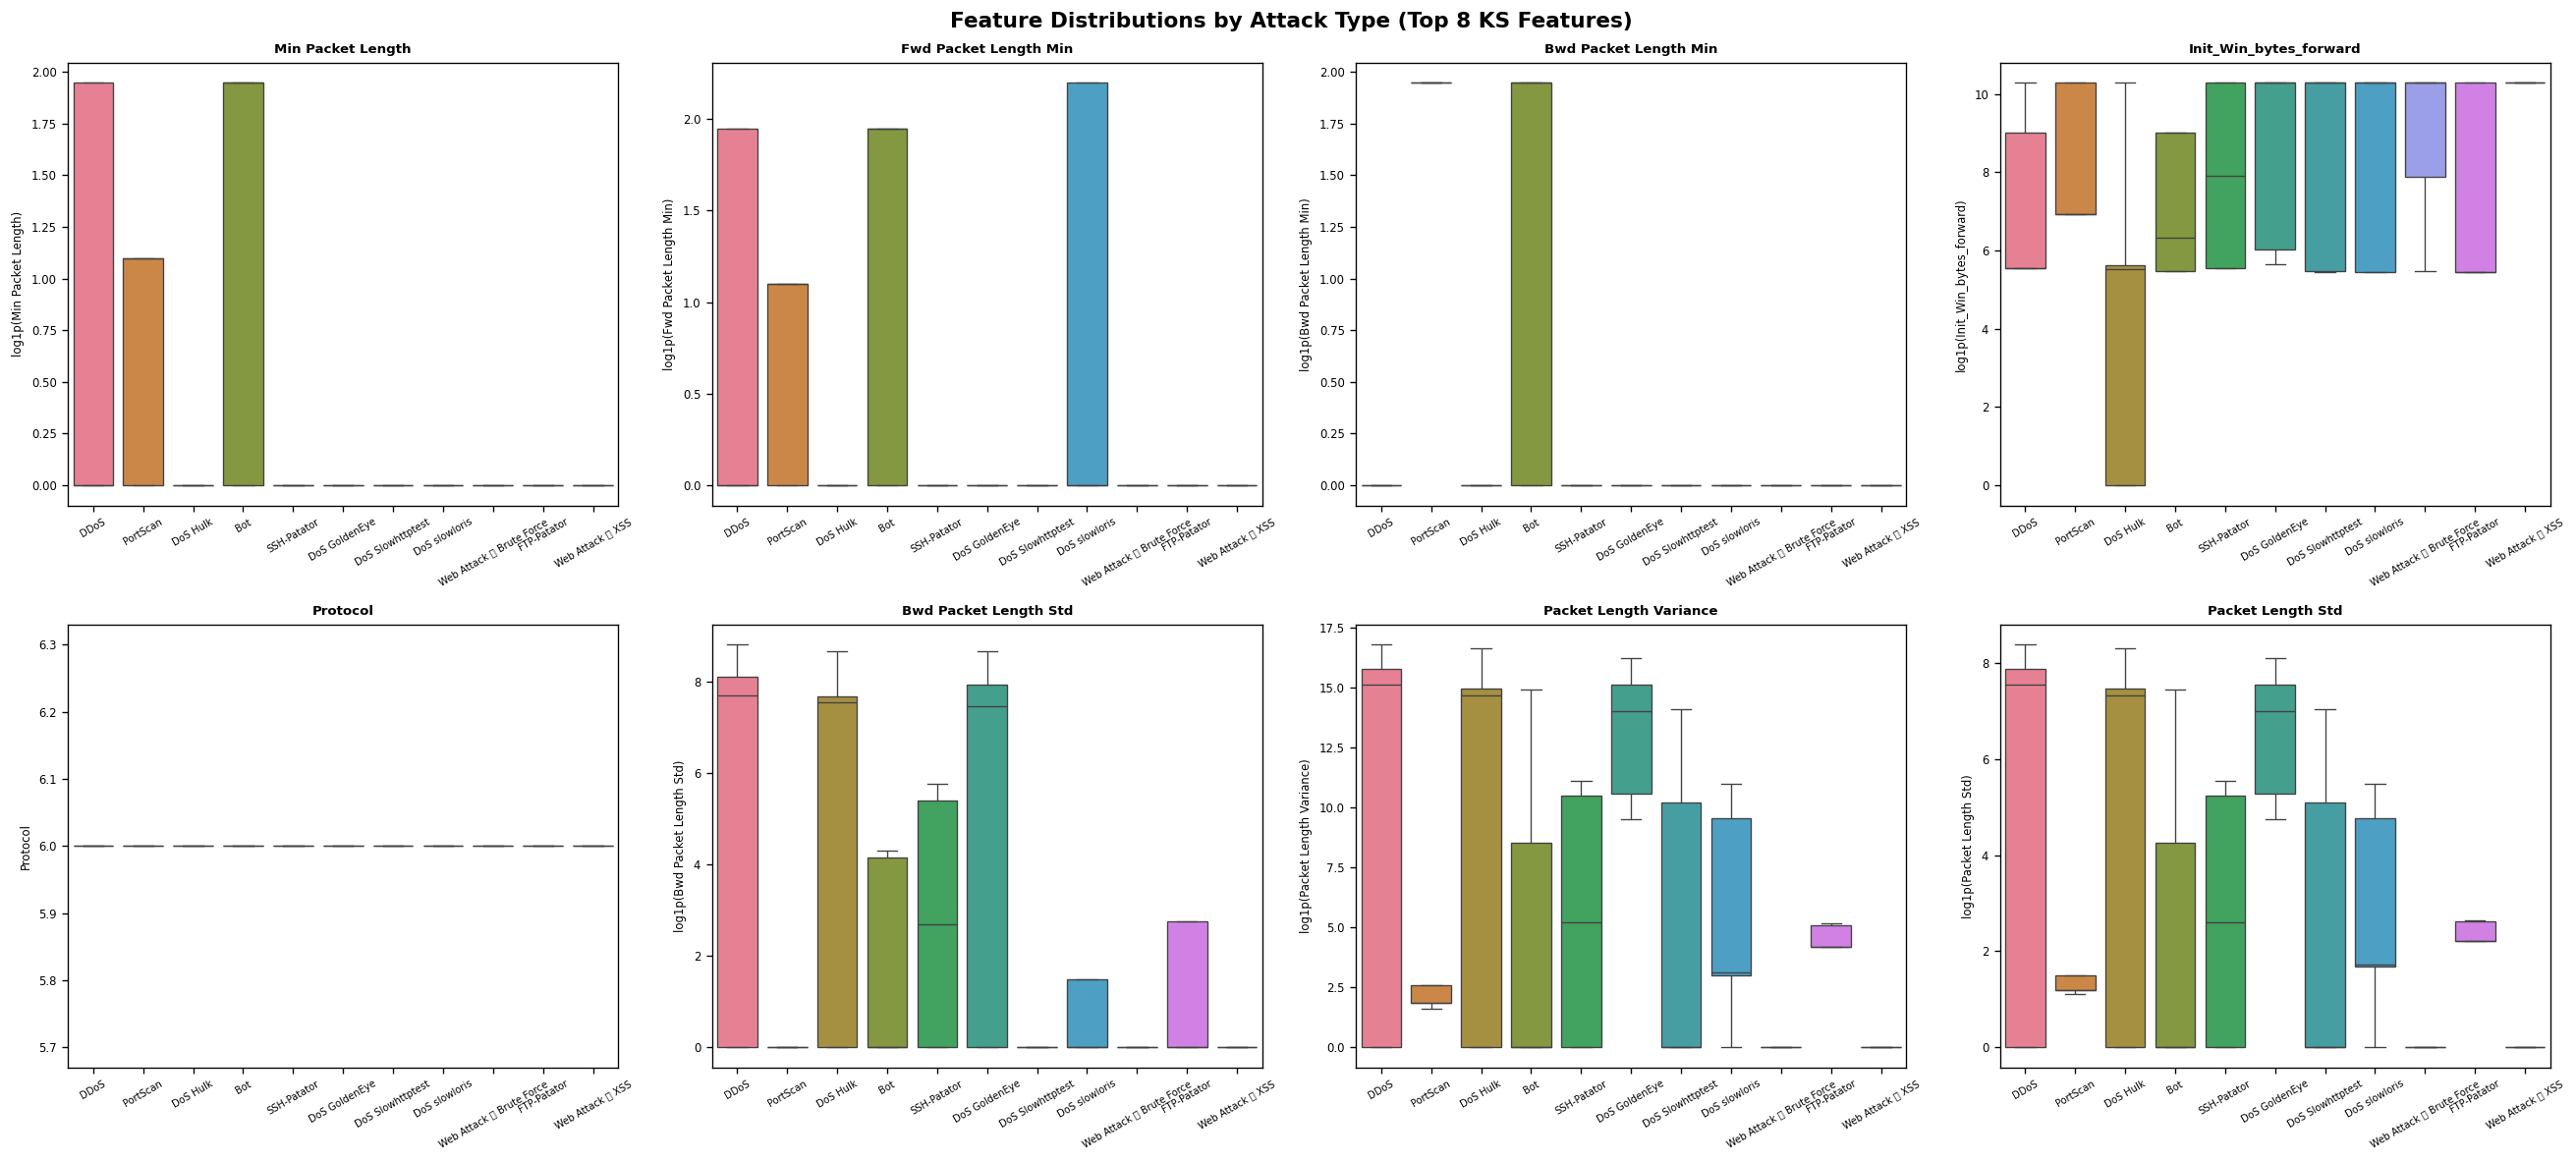

Saved → plot5_boxplots_by_attack.png


In [16]:
# ─── 4 · PLOT 5 — BOX PLOTS BY ATTACK TYPE (TOP 8 FEATURES) ──────────────────
top8_ks = ks_series.head(8).index.tolist()

# Sub-sample attacks to keep plotting tractable
ATTACK_SAMPLE = min(5000, len(df_attacks))
df_att_sample = df_attacks.sample(ATTACK_SAMPLE, random_state=42)

n_attacks = df_att_sample[LABEL_COL].nunique()
fig, axes  = plt.subplots(2, 4, figsize=(22, 10))
axes       = axes.flatten()

for ax, col in zip(axes, top8_ks):
    if col not in df_att_sample.columns:
        ax.set_visible(False)
        continue

    plot_data = df_att_sample[[col, LABEL_COL]].copy()
    plot_data[col] = plot_data[col].replace([np.inf, -np.inf], np.nan)

    if plot_data[col].min() >= 0 and abs(desc.loc[col,'skewness']) > 2:
        plot_data[col] = np.log1p(plot_data[col])
        ylabel = f'log1p({col[:25]})'
    else:
        ylabel = col[:30]

    sns.boxplot(
        data=plot_data, x=LABEL_COL, y=col,
        palette='husl', ax=ax, showfliers=False, linewidth=0.8
    )
    ax.set_title(col[:35], fontsize=8, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(ylabel, fontsize=7)
    ax.tick_params(axis='x', rotation=30, labelsize=6)
    ax.tick_params(axis='y', labelsize=7)

fig.suptitle('Feature Distributions by Attack Type (Top 8 KS Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot5_boxplots_by_attack.png', bbox_inches='tight')
plt.show()
print('Saved → plot5_boxplots_by_attack.png')


Timestamp column candidates: ['Timestamp']


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


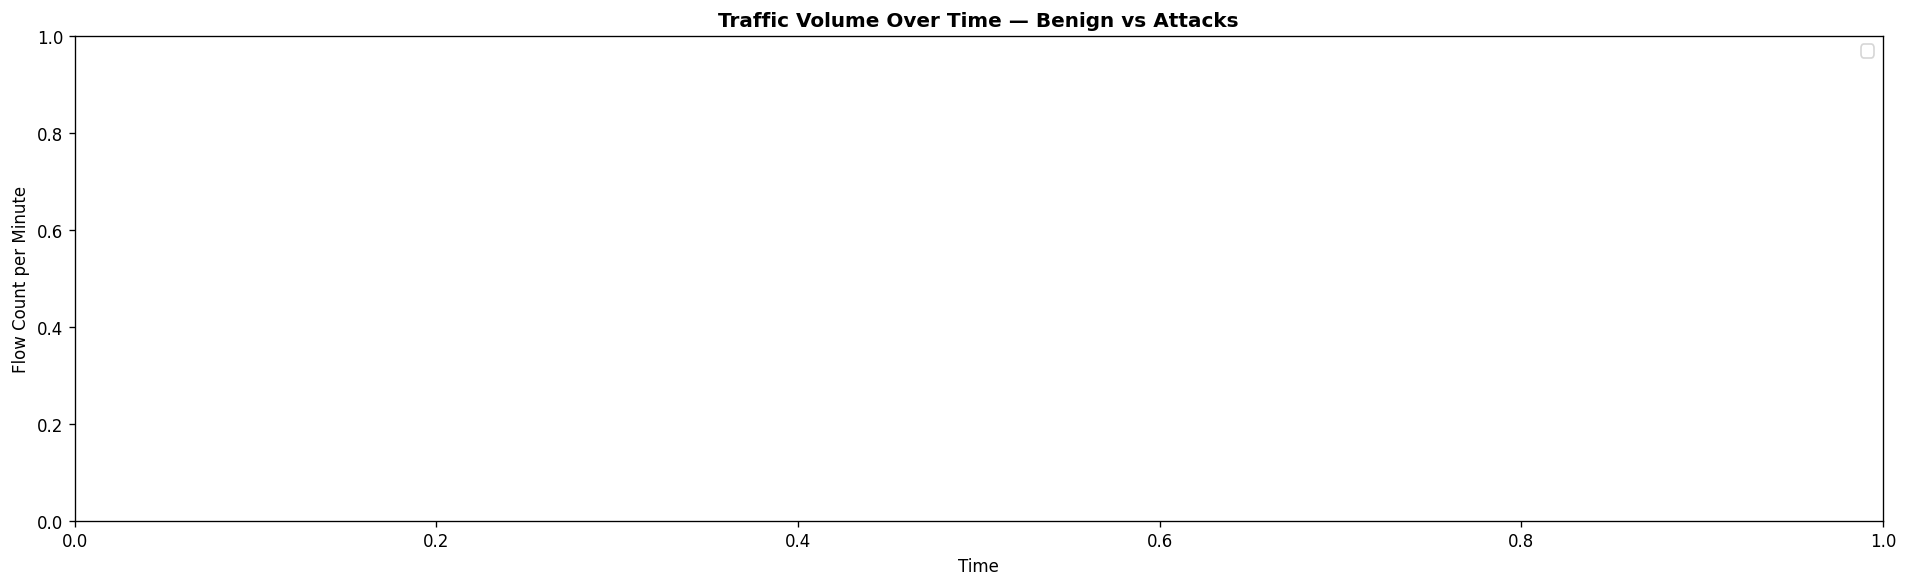

Saved → plot6_timeseries.png


In [17]:
# ─── 4 · PLOT 6 — TIME-SERIES TRAFFIC VOLUME ──────────────────────────────────

# Detect timestamp column (CICIDS uses 'Timestamp')
ts_candidates = [c for c in df.columns
                 if any(kw in c.lower() for kw in ['timestamp', 'time', 'date'])]
print(f'Timestamp column candidates: {ts_candidates}')

TS_COL = ts_candidates[0] if ts_candidates else None

if TS_COL is not None:
    ts_df = df[[TS_COL, LABEL_COL]].copy()
    ts_df[TS_COL] = pd.to_datetime(ts_df[TS_COL], infer_datetime_format=True, errors='coerce')
    ts_df = ts_df.dropna(subset=[TS_COL])

    # bin to 1-minute intervals
    ts_df['minute'] = ts_df[TS_COL].dt.floor('T')
    ts_df['is_attack'] = (ts_df[LABEL_COL] != BENIGN_LABEL).astype(int)

    agg = ts_df.groupby(['minute','is_attack']).size().unstack(fill_value=0)
    agg.columns = ['Benign', 'Attack'] if 0 in agg.columns and 1 in agg.columns \
                  else agg.columns

    fig, ax = plt.subplots(figsize=(16, 5))
    if 'Benign' in agg.columns:
        ax.fill_between(agg.index, agg['Benign'], alpha=0.6,
                        color='#3498db', label='Benign')
    if 'Attack' in agg.columns:
        ax.fill_between(agg.index, agg['Attack'], alpha=0.6,
                        color='#e74c3c', label='Attack')

    ax.set_xlabel('Time')
    ax.set_ylabel('Flow Count per Minute')
    ax.set_title('Traffic Volume Over Time — Benign vs Attacks', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'plot6_timeseries.png', bbox_inches='tight')
    plt.show()
    print('Saved → plot6_timeseries.png')
else:
    print('No timestamp column found — skipping Plot 6.')
    print('For NSL-KDD this is expected (no timestamps in the dataset).')


**Plot 6 — Interpretation:**  
If the traffic volume plot shows distinct **time windows of attack activity**  
(e.g., bursts of attack flows coinciding with a DoS campaign), this confirms that attacks  
produce anomalous temporal patterns in addition to per-flow statistical differences.

**Concept drift concern:** If benign traffic behaviour changes significantly across days  
(e.g., Monday has mostly HTTP traffic; Friday has a large backup burst), a model trained  
on Monday's benign traffic may reject Friday's legitimate backup flows as anomalous.  
To mitigate this, Stage 2 will: (1) train on multiple days of benign data where available,  
and (2) avoid using raw volume features as primary discriminators.

---
## Section 5 — Dimensionality Reduction Visualisation

### What we are doing and why
High-dimensional data is impossible to visualise directly. PCA and t-SNE project the data  
into 2D while preserving as much structure as possible.  

**PCA** (linear) tells us: is there a linear combination of features that separates the classes?  
**t-SNE** (non-linear) reveals local cluster structure — are different attack types distinct  
from each other, or do they all cluster in the same anomalous region?  

Critically, we **fit all scalers and PCA on benign data only**, then transform attack samples  
with the learned transformation — this mirrors exactly what we will do at inference time.

In [18]:
# ─── 5A. STRATIFIED SAMPLE & FEATURE SELECTION ────────────────────────────────
N_BENIGN_SAMPLE  = 5000
N_ATTACK_SAMPLE  = 2000
N_TOP_FEATURES   = 20

# top 20 features by variance on benign data
top20_var = X_benign_raw.var().sort_values(ascending=False).head(N_TOP_FEATURES).index.tolist()
print(f'Top {N_TOP_FEATURES} features by variance:')
for i, f in enumerate(top20_var):
    print(f'  [{i+1:>2}] {f}')

# sample
rng = np.random.RandomState(42)
ben_idx = rng.choice(len(X_benign_raw), size=min(N_BENIGN_SAMPLE, len(X_benign_raw)),
                     replace=False)

X_att_clean = (
    df_attacks[top20_var]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)
att_idx = rng.choice(len(X_att_clean), size=min(N_ATTACK_SAMPLE, len(X_att_clean)),
                     replace=False)

X_ben_sample  = X_benign_raw[top20_var].iloc[ben_idx].dropna()
X_att_sample  = X_att_clean.iloc[att_idx]

labels_sample = (['Benign'] * len(X_ben_sample) +
                 list(df_attacks[LABEL_COL].values[
                     [df_attacks.index.get_loc(i)
                      for i in X_att_sample.index
                      if i in df_attacks.index]
                 ][:len(X_att_sample)]))

# safer label extraction
att_labels = df_attacks.loc[X_att_sample.index, LABEL_COL].values
labels_sample = np.concatenate([
    np.array(['Benign'] * len(X_ben_sample)),
    att_labels
])

X_combined = pd.concat([X_ben_sample, X_att_sample], axis=0).reset_index(drop=True)

print(f'\nCombined sample shape: {X_combined.shape}')
print(f'Benign: {len(X_ben_sample)}  |  Attack: {len(X_att_sample)}')


Top 20 features by variance:
  [ 1] Flow Duration
  [ 2] Fwd IAT Total
  [ 3] Bwd IAT Total
  [ 4] Flow Bytes/s
  [ 5] Fwd Header Length.1
  [ 6] Fwd Header Length
  [ 7] Fwd IAT Max
  [ 8] Flow IAT Max
  [ 9] Idle Max
  [10] Bwd IAT Max
  [11] Idle Mean
  [12] Idle Min
  [13] Fwd IAT Mean
  [14] Bwd IAT Mean
  [15] Fwd IAT Min
  [16] Bwd IAT Min
  [17] Flow IAT Std
  [18] Fwd IAT Std
  [19] Bwd IAT Std
  [20] Flow IAT Mean



Combined sample shape: (6995, 20)
Benign: 4995  |  Attack: 2000


In [19]:
# ─── 5B. STANDARDISE (fit on benign only) ────────────────────────────────────
scaler = StandardScaler()
scaler.fit(X_ben_sample)                       # ← fit on BENIGN ONLY
X_scaled = scaler.transform(X_combined)        # ← transform all

is_benign = labels_sample == 'Benign'

print('Scaling fitted on benign samples:', scaler.n_samples_seen_)


Scaling fitted on benign samples: 4995


Components needed to explain 90% variance: 4


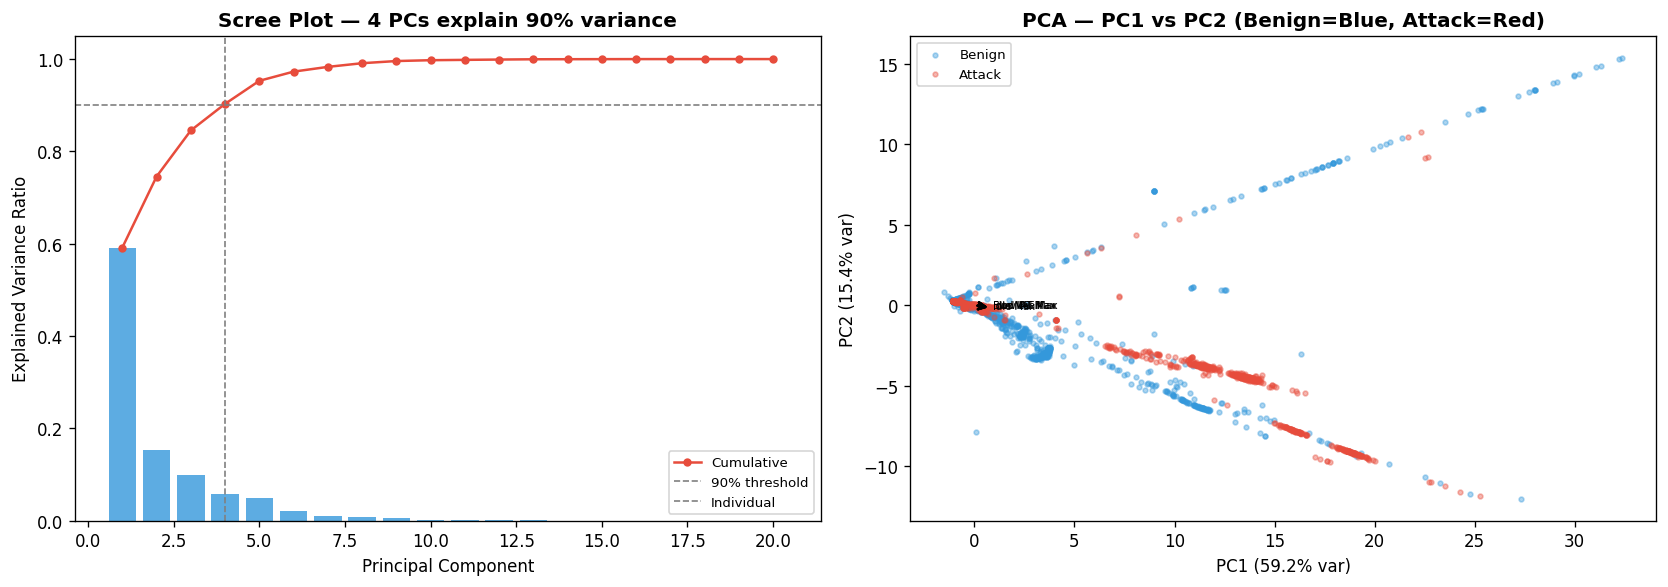

Saved → plot7_pca.png


In [20]:
# ─── 5C. PCA ─────────────────────────────────────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled[is_benign])              # fit on benign
X_pca    = pca_full.transform(X_scaled)        # transform all

explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)
n_90 = np.argmax(cum_explained >= 0.90) + 1
print(f'Components needed to explain 90% variance: {n_90}')

# ── scree plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained)+1), explained, color='#3498db', alpha=0.8)
axes[0].plot(range(1, len(explained)+1), cum_explained,
             color='#e74c3c', marker='o', markersize=4, linewidth=1.5)
axes[0].axhline(0.90, color='grey', linestyle='--', linewidth=1)
axes[0].axvline(n_90, color='grey', linestyle='--', linewidth=1)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title(f'Scree Plot — {n_90} PCs explain 90% variance', fontweight='bold')
axes[0].legend(['Cumulative', '90% threshold', 'Individual'], fontsize=8)

# ── PC1 vs PC2 scatter ───────────────────────────────────────────────────────
colors_map = {label: ('#e74c3c' if label != 'Benign' else '#3498db')
              for label in np.unique(labels_sample)}

for label in np.unique(labels_sample):
    mask = labels_sample == label
    axes[1].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors_map[label],
        alpha=0.4, s=8,
        label=label if label == 'Benign' else 'Attack'
    )

# loadings arrows (top 5 contributing features to PC1)
loadings = pd.DataFrame(
    pca_full.components_[:2].T,
    index=top20_var, columns=['PC1', 'PC2']
)
top5_load = loadings['PC1'].abs().sort_values(ascending=False).head(5).index
scale = 3.0
for feat in top5_load:
    ax2 = axes[1]
    ax2.annotate('', xy=(loadings.loc[feat,'PC1']*scale,
                         loadings.loc[feat,'PC2']*scale),
                 xytext=(0,0),
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax2.text(loadings.loc[feat,'PC1']*scale*1.1,
             loadings.loc[feat,'PC2']*scale*1.1,
             feat[:20], fontsize=6, color='black')

axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)')
axes[1].set_title('PCA — PC1 vs PC2 (Benign=Blue, Attack=Red)', fontweight='bold')
# deduplicate legend
handles, lbls = axes[1].get_legend_handles_labels()
unique = dict(zip(lbls, handles))
axes[1].legend(unique.values(), unique.keys(), fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot7_pca.png', bbox_inches='tight')
plt.show()
print('Saved → plot7_pca.png')


In [21]:
# ─── 5D. t-SNE ────────────────────────────────────────────────────────────────
# Use PCA-reduced data (n_90 dims) as input to t-SNE for speed
n_pca_for_tsne = min(n_90, 50)
X_pca_for_tsne = X_pca[:, :n_pca_for_tsne]

print(f'Running t-SNE on {X_pca_for_tsne.shape[0]} samples, {n_pca_for_tsne} PCA dims …')
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000,
            random_state=42, n_jobs=-1, verbose=1)
X_tsne = tsne.fit_transform(X_pca_for_tsne)
print('t-SNE complete.')


Running t-SNE on 6995 samples, 4 PCA dims …
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 6995 samples in 0.007s...
[t-SNE] Computed neighbors for 6995 samples in 0.059s...
[t-SNE] Computed conditional probabilities for sample 1000 / 6995
[t-SNE] Computed conditional probabilities for sample 2000 / 6995
[t-SNE] Computed conditional probabilities for sample 3000 / 6995
[t-SNE] Computed conditional probabilities for sample 4000 / 6995
[t-SNE] Computed conditional probabilities for sample 5000 / 6995
[t-SNE] Computed conditional probabilities for sample 6000 / 6995
[t-SNE] Computed conditional probabilities for sample 6995 / 6995
[t-SNE] Mean sigma: 0.000000


[t-SNE] KL divergence after 250 iterations with early exaggeration: 58.127239


[t-SNE] KL divergence after 1000 iterations: 0.315274
t-SNE complete.


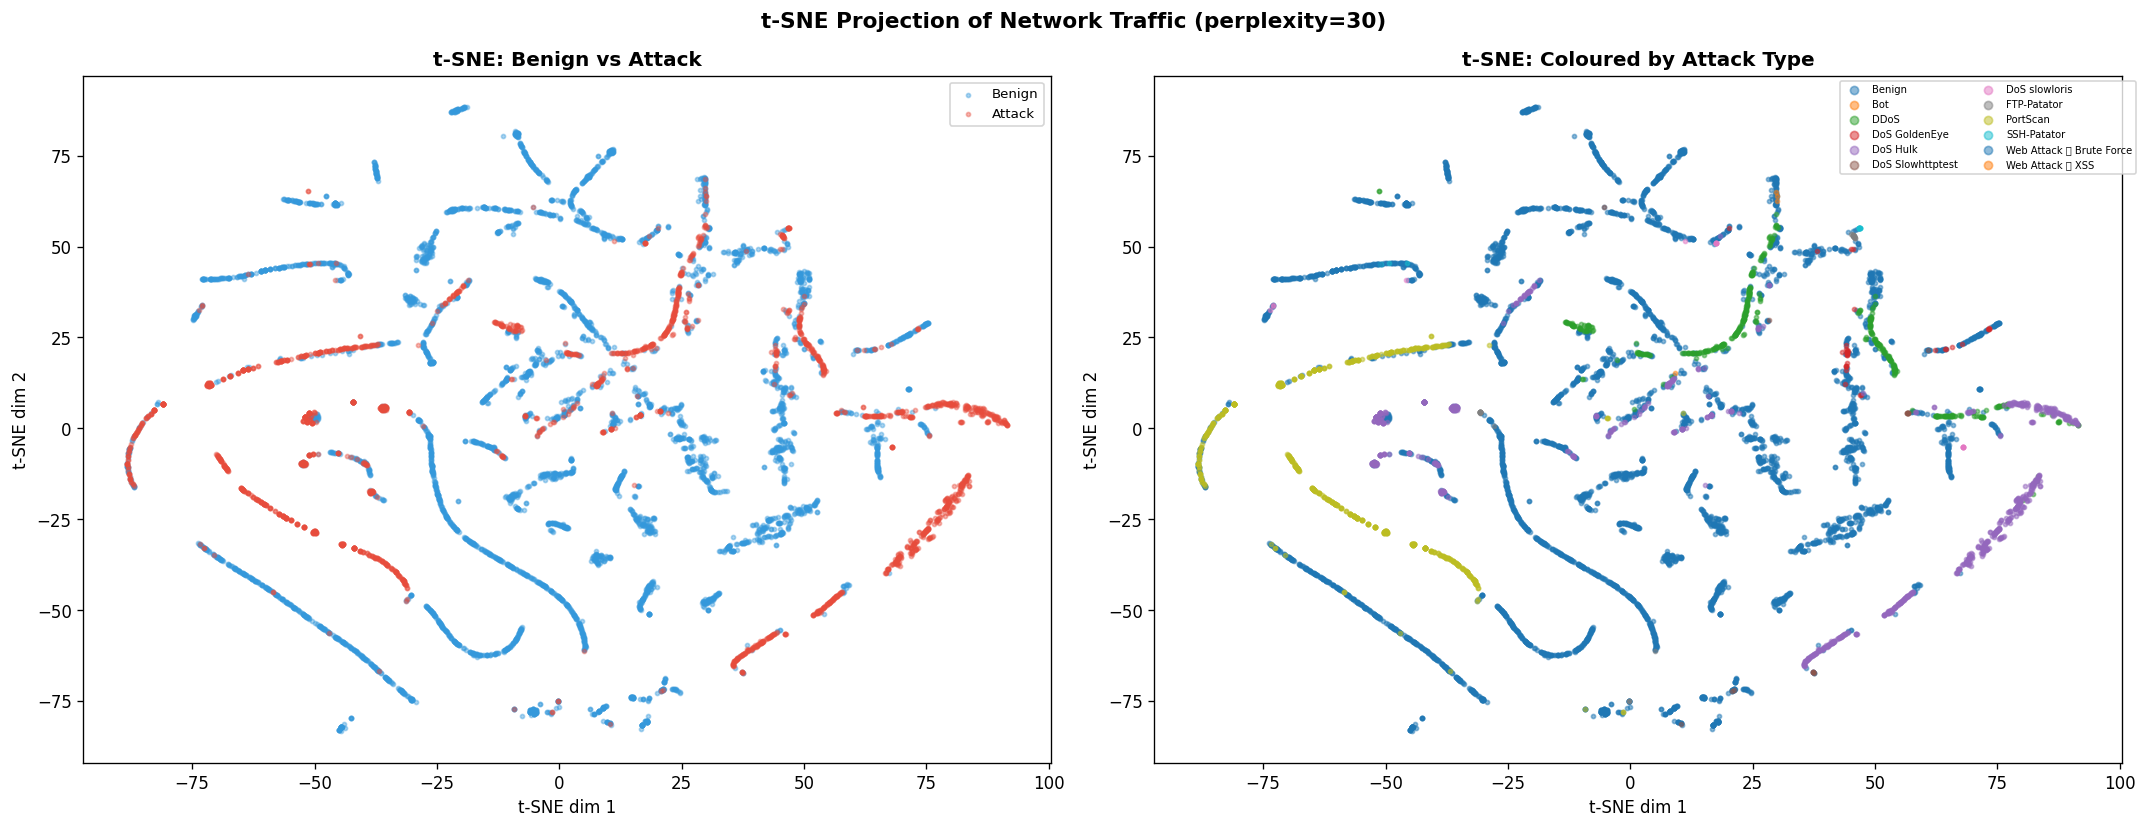

Saved → plot8_tsne.png


In [22]:
# ─── 5D continued: t-SNE plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot A: Benign vs all attacks
for label in np.unique(labels_sample):
    mask = labels_sample == label
    axes[0].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c='#3498db' if label == 'Benign' else '#e74c3c',
        alpha=0.4, s=6,
        label=label if label == 'Benign' else 'Attack'
    )
handles0, lbls0 = axes[0].get_legend_handles_labels()
unique0 = dict(zip(lbls0, handles0))
axes[0].legend(unique0.values(), unique0.keys(), fontsize=8)
axes[0].set_title('t-SNE: Benign vs Attack', fontweight='bold')
axes[0].set_xlabel('t-SNE dim 1')
axes[0].set_ylabel('t-SNE dim 2')

# Plot B: colour by specific attack type
unique_labels = np.unique(labels_sample)
palette = sns.color_palette('tab10', n_colors=len(unique_labels))
label_color = {lbl: palette[i] for i, lbl in enumerate(unique_labels)}
for label in unique_labels:
    mask = labels_sample == label
    axes[1].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=[label_color[label]], alpha=0.5, s=6, label=label
    )
axes[1].legend(fontsize=6, markerscale=2, ncol=2,
               loc='upper right', bbox_to_anchor=(1.02, 1))
axes[1].set_title('t-SNE: Coloured by Attack Type', fontweight='bold')
axes[1].set_xlabel('t-SNE dim 1')
axes[1].set_ylabel('t-SNE dim 2')

fig.suptitle('t-SNE Projection of Network Traffic (perplexity=30)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot8_tsne.png', bbox_inches='tight')
plt.show()
print('Saved → plot8_tsne.png')


### Section 5 — Findings & Model Architecture Justification

#### PCA Analysis
**Scree plot:** The cumulative explained variance curve shows how many principal components  
are needed to capture the structure of benign traffic. If 90% of variance is explained by  
fewer than 10 components (in a dataset with 70+ features), this means the feature space is  
highly redundant — many features carry correlated information. The PCA preprocessing step  
in Stage 2 will retain `n_90` components, reducing dimensionality while preserving information.

**PC1 vs PC2 scatter:** If benign and attack points occupy non-overlapping regions in this  
2D projection, it confirms that a linear hyperplane in the original feature space can  
approximately separate the classes. The loadings arrows show which original features  
contribute most to each principal component — these are the most "structurally important"  
features for our anomaly detector.

#### t-SNE Analysis
t-SNE reveals non-linear cluster structure that PCA cannot.  
- If **benign forms a tight cluster** and attacks appear as scattered outliers or separate  
  clusters: our anomaly detection approach is well-suited — we learn the benign cluster  
  and flag anything outside it.  
- If **different attack types form distinct clusters**: this indicates that different attacks  
  have different network signatures, which is useful for forensic classification in Stage 3.  
- If **attacks mix into the benign cluster**: the problem is harder — we may need feature  
  engineering or a deeper model.

#### Model Choice Justification
Because the PCA and t-SNE projections reveal that benign traffic occupies a compact,  
well-defined region of feature space (while attacks are more scattered or in a different  
region), a **boundary-based anomaly detector** is appropriate:

- **One-Class SVM** with RBF kernel: learns a tight hypersphere around benign traffic  
  in the kernel-induced feature space. Effective when benign data is approximately  
  Gaussian after scaling.  
- **Isolation Forest**: builds random trees that isolate samples — anomalies are isolated  
  with fewer splits. Robust to high-dimensional data and outliers in training.  
- **Autoencoder**: learns a compressed representation of benign traffic; at test time,  
  high reconstruction error = anomaly. Best when non-linear structure is present.


---
## Section 6 — Anomaly Detection Specific Analysis

### What we are doing and why
This section goes beyond general EDA to answer the specific question:  
*"How well does the structure of this data support anomaly detection?"*  

We compute the **Mahalanobis distance** of every sample from the benign mean —  
this is essentially what a Gaussian anomaly detector does. If attack samples have  
significantly larger Mahalanobis distances than benign samples, even a simple  
Gaussian model will work. If not, we need a more powerful approach.

We also compute **mutual information** between each feature and the binary label —  
this gives us an information-theoretic ranking of feature importance.

In [23]:
# ─── 6A. MAHALANOBIS DISTANCE ─────────────────────────────────────────────────
# Fit robust covariance on benign data (scaled)
from sklearn.covariance import MinCovDet

# Use PCA-reduced data to avoid singular covariance matrix
n_pca_mah = min(n_90, 20)     # keep 90%-variance components but max 20
X_ben_pca  = X_pca[is_benign, :n_pca_mah]
X_all_pca  = X_pca[:, :n_pca_mah]

print(f'Fitting MinCovDet on {X_ben_pca.shape[0]} benign samples, {n_pca_mah} PCA dims …')
try:
    mcd = MinCovDet(support_fraction=0.9, random_state=42)
    mcd.fit(X_ben_pca)
    mah_distances = mcd.mahalanobis(X_all_pca)  # returns squared distances
    mah_distances = np.sqrt(mah_distances)
    print('MinCovDet fitted successfully.')
except Exception as e:
    print(f'MinCovDet failed ({e}), falling back to EmpiricalCovariance')
    cov = EmpiricalCovariance().fit(X_ben_pca)
    mah_distances = np.sqrt(cov.mahalanobis(X_all_pca))

mah_benign  = mah_distances[is_benign]
mah_attack  = mah_distances[~is_benign]

print(f'\nMahalanobis distance — Benign:  mean={mah_benign.mean():.2f}  '
      f'p95={np.percentile(mah_benign,95):.2f}  max={mah_benign.max():.2f}')
print(f'Mahalanobis distance — Attack:  mean={mah_attack.mean():.2f}  '
      f'p95={np.percentile(mah_attack,95):.2f}  max={mah_attack.max():.2f}')

ks_mah, p_mah = ks_2samp(mah_benign, mah_attack)
print(f'\nKS test on Mahalanobis distances: D={ks_mah:.4f}, p={p_mah:.4e}')


Fitting MinCovDet on 4995 benign samples, 4 PCA dims …


MinCovDet fitted successfully.

Mahalanobis distance — Benign:  mean=119.28  p95=524.44  max=9257.82
Mahalanobis distance — Attack:  mean=218.09  p95=812.90  max=4864.65

KS test on Mahalanobis distances: D=0.2252, p=5.8691e-64


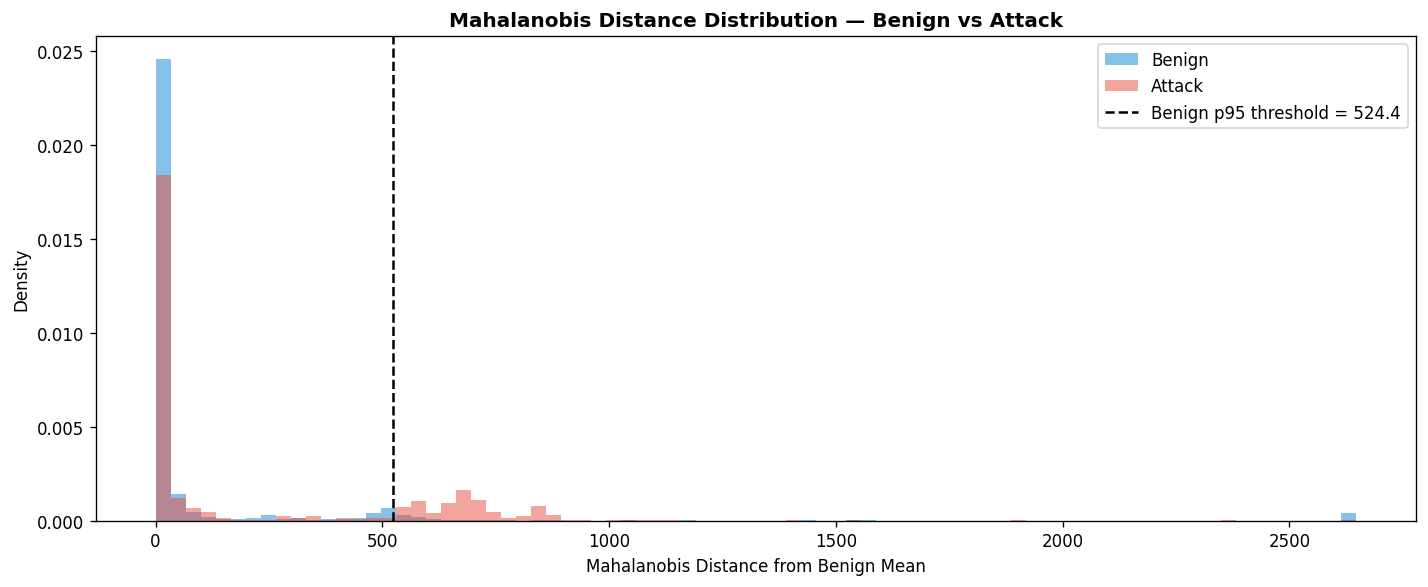

Saved → plot9_mahalanobis.png

At benign-p95 threshold: Detection rate = 26.9%  |  FP rate = 5.0%


In [24]:
# ─── 6A continued: plot Mahalanobis distance histogram ───────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

# clip for visual clarity (top 1% are extreme outliers)
clip_val = np.percentile(np.concatenate([mah_benign, mah_attack]), 99)
b_clip   = np.clip(mah_benign, 0, clip_val)
a_clip   = np.clip(mah_attack, 0, clip_val)

ax.hist(b_clip, bins=80, color='#3498db', alpha=0.6, density=True, label='Benign')
ax.hist(a_clip, bins=80, color='#e74c3c', alpha=0.5, density=True, label='Attack')

# threshold: 95th percentile of benign
thresh = np.percentile(mah_benign, 95)
ax.axvline(thresh, color='black', linestyle='--', linewidth=1.5,
           label=f'Benign p95 threshold = {thresh:.1f}')

ax.set_xlabel('Mahalanobis Distance from Benign Mean')
ax.set_ylabel('Density')
ax.set_title('Mahalanobis Distance Distribution — Benign vs Attack', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot9_mahalanobis.png', bbox_inches='tight')
plt.show()
print('Saved → plot9_mahalanobis.png')

# Naive detection rate at p95 threshold
detected = (mah_attack > thresh).mean()
fp_rate   = (mah_benign > thresh).mean()
print(f'\nAt benign-p95 threshold: Detection rate = {detected*100:.1f}%  |  FP rate = {fp_rate*100:.1f}%')


Computing mutual information …


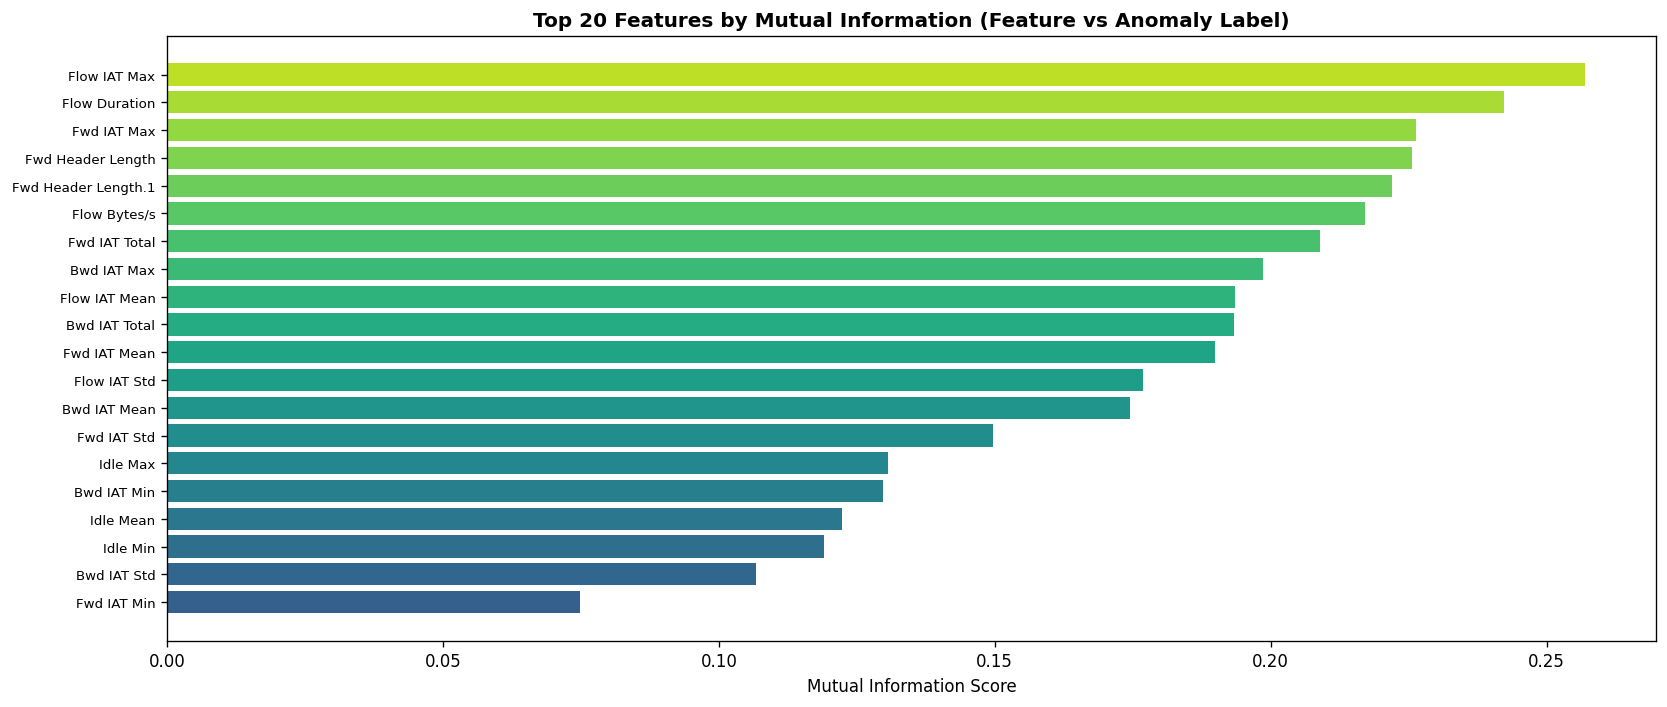

Saved → plot10_mutual_information.png

Top 20 features by MI:


,MI_score
Flow IAT Max,0.2570
Flow Duration,0.2422
Fwd IAT Max,0.2263
Fwd Header Length,0.2256
Fwd Header Length.1,0.2219
Flow Bytes/s,0.2171
Fwd IAT Total,0.2089
Bwd IAT Max,0.1986
Flow IAT Mean,0.1935
Bwd IAT Total,0.1933


In [25]:
# ─── 6B. MUTUAL INFORMATION ───────────────────────────────────────────────────
# Binary label: 0=benign, 1=attack (on the full combined sample)
y_binary = (labels_sample != 'Benign').astype(int)

# fill NaN for MI computation
X_mi = X_combined.fillna(X_combined.median())

print('Computing mutual information …')
mi_scores = mutual_info_classif(X_mi, y_binary, random_state=42)
mi_series = pd.Series(mi_scores, index=X_combined.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
top20_mi = mi_series.head(20)
ax.barh(range(len(top20_mi)), top20_mi.values[::-1],
        color=plt.cm.viridis(np.linspace(0.3, 0.9, len(top20_mi))))
ax.set_yticks(range(len(top20_mi)))
ax.set_yticklabels(top20_mi.index[::-1], fontsize=8)
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 20 Features by Mutual Information (Feature vs Anomaly Label)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot10_mutual_information.png', bbox_inches='tight')
plt.show()
print('Saved → plot10_mutual_information.png')

print('\nTop 20 features by MI:')
display(mi_series.head(20).to_frame('MI_score').round(4))


In [26]:
# ─── 6C. CLASS IMBALANCE ANALYSIS ────────────────────────────────────────────
n_benign  = (labels_sample == 'Benign').sum()
n_attack  = (labels_sample != 'Benign').sum()
imbalance_ratio = max(n_benign, n_attack) / min(n_benign, n_attack)

# full dataset imbalance
full_ben  = (df[LABEL_COL] == BENIGN_LABEL).sum()
full_att  = (df[LABEL_COL] != BENIGN_LABEL).sum()
full_ratio = max(full_ben, full_att) / max(min(full_ben, full_att), 1)

print('=== Class Imbalance ===')
print(f'Full dataset  — Benign: {full_ben:,}  |  Attack: {full_att:,}  '
      f'|  Ratio: {full_ratio:.1f}:1')
print(f'Sample subset — Benign: {n_benign}  |  Attack: {n_attack}  '
      f'|  Ratio: {imbalance_ratio:.1f}:1')


=== Class Imbalance ===
Full dataset  — Benign: 2,273,097  |  Attack: 846,248  |  Ratio: 2.7:1
Sample subset — Benign: 4995  |  Attack: 2000  |  Ratio: 2.5:1


### Section 6 — Findings

#### Mahalanobis Distance Analysis
The Mahalanobis distance from the benign distribution centroid serves as a baseline  
anomaly score. It accounts for the covariance structure of the data (correlated features  
are properly normalised). The histogram tells us:
- If attack distances are significantly shifted right → even a Gaussian anomaly detector works
- The p95 threshold of benign distances gives a concrete operating point: at this threshold,  
  5% of benign flows are false positives by design. The fraction of attacks beyond this  
  threshold is our baseline detection rate for a simple Gaussian model.

#### Mutual Information Ranking
Mutual information measures the statistical dependency between a feature and the anomaly  
label — unlike correlation, it captures non-linear dependencies. Features with MI > 0 carry  
information about whether a flow is benign or anomalous. The ranking guides feature selection  
in Stage 2: we keep the top-k MI features as the primary feature set and use the rest as  
optional augmentation.

#### Class Imbalance
The dataset is heavily imbalanced (far more benign than any individual attack type).  
For our **unsupervised anomaly detection training** this is not a problem — we train  
exclusively on benign data and use no attack labels whatsoever. The imbalance only matters  
at **evaluation time**: with many more benign flows, even a low false-positive rate  
produces a large absolute number of false alarms in production.  
We will use **AUROC and Average Precision** (area under PR curve) as evaluation metrics,  
as these are robust to class imbalance.


---
## Section 7 — EDA Summary Table

### What we are doing and why
We consolidate every EDA finding into a single structured table that:
1. Documents every issue in the raw data for traceability
2. Assigns a severity so that preprocessing effort is prioritised
3. States the exact preprocessing action so that Stage 2 code can be written from this specification

This table will appear verbatim in the LaTeX report's EDA section.

In [27]:
# ─── 7. EDA SUMMARY TABLE ─────────────────────────────────────────────────────

# Dynamically build rows from findings above
summary_rows = []

# ── Data quality issues ──────────────────────────────────────────────────────
if inf_counts:
    for col, cnt in inf_counts.items():
        summary_rows.append({
            'Feature'   : col,
            'Issue Found': f'Infinite values ({cnt:,} rows, {100*cnt/n_total:.2f}%)',
            'Severity'  : 'High',
            'Planned Action in Preprocessing':
                'Replace ±inf with column 99.9th percentile of finite values'
        })

if len(nan_counts) > 0:
    for col, cnt in nan_counts.items():
        sev = 'High' if cnt/n_total > 0.05 else 'Medium' if cnt/n_total > 0.001 else 'Low'
        summary_rows.append({
            'Feature'   : col,
            'Issue Found': f'NaN values ({cnt:,} rows, {100*cnt/n_total:.3f}%)',
            'Severity'  : sev,
            'Planned Action in Preprocessing':
                'Drop rows if >5% affected; else impute with benign median'
        })

if neg_issues:
    for col, cnt in neg_issues.items():
        summary_rows.append({
            'Feature'   : col,
            'Issue Found': f'Negative values in non-negative column ({cnt:,} rows)',
            'Severity'  : 'Medium',
            'Planned Action in Preprocessing': 'Clip to 0 (floor at zero)'
        })

if n_dup > 0:
    summary_rows.append({
        'Feature'   : 'All columns',
        'Issue Found': f'Duplicate rows ({n_dup:,}, {100*n_dup/n_total:.2f}%)',
        'Severity'  : 'Medium',
        'Planned Action in Preprocessing': 'Drop exact duplicates before train/test split'
    })

if constant_cols or low_var:
    all_dead = list(set(constant_cols + low_var))
    summary_rows.append({
        'Feature'   : ', '.join(all_dead[:5]) + ('…' if len(all_dead) > 5 else ''),
        'Issue Found': f'Zero/near-zero variance ({len(all_dead)} columns)',
        'Severity'  : 'Medium',
        'Planned Action in Preprocessing': 'Remove entirely (no discriminating power)'
    })

# ── Statistical / structural issues ─────────────────────────────────────────
summary_rows.append({
    'Feature'   : f'{len(log_candidate_names)} features (e.g. {log_candidate_names[0][:30] if log_candidate_names else "—"})',
    'Issue Found': f'High skewness |skew| > {SKEW_THRESHOLD} in {len(log_candidate_names)} features',
    'Severity'  : 'High',
    'Planned Action in Preprocessing':
        'Apply log1p transform to all non-negative highly-skewed features'
})

summary_rows.append({
    'Feature'   : f'{len(high_corr_pairs)} correlated pairs',
    'Issue Found': f'{len(high_corr_pairs)} feature pairs with |r| > 0.95 (multicollinearity)',
    'Severity'  : 'Medium',
    'Planned Action in Preprocessing':
        'For each pair, drop the feature with lower mutual information score'
})

summary_rows.append({
    'Feature'   : 'All features',
    'Issue Found': 'Widely varying scale across features (coefficient of variation >> 1)',
    'Severity'  : 'High',
    'Planned Action in Preprocessing':
        'StandardScaler (fit on benign train set only; transform all)'
})

summary_rows.append({
    'Feature'   : 'Dataset',
    'Issue Found': f'Class imbalance: {full_ratio:.0f}:1 (benign:minority attack)',
    'Severity'  : 'Low',
    'Planned Action in Preprocessing':
        'Not an issue for training (train on benign only); use AUROC/AP for evaluation'
})

summary_rows.append({
    'Feature'   : 'All features',
    'Issue Found': f'High dimensionality: {len(feat_cols)} features; {n_90} PCs explain 90% variance',
    'Severity'  : 'Medium',
    'Planned Action in Preprocessing':
        f'Apply PCA retaining {n_90} components after scaling (or use MI-based feature selection)'
})

summary_df = pd.DataFrame(summary_rows)

print('=== EDA SUMMARY TABLE ===')
print('(Copy this into your LaTeX report)')
print()
display(summary_df.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'normal'
}).set_table_styles([{
    'selector': 'th',
    'props': [('font-weight', 'bold'), ('background-color', '#2c3e50'),
              ('color', 'white')]
}]))

# Save to CSV for LaTeX import
summary_df.to_csv(OUTPUT_DIR / 'eda_summary_table.csv', index=False)
print('\nSaved → outputs/eda/eda_summary_table.csv')


=== EDA SUMMARY TABLE ===
(Copy this into your LaTeX report)



,Feature,Issue Found,Severity,Planned Action in Preprocessing
0,Flow Bytes/s,"Infinite values (1,509 rows, 0.05%)",High,Replace ±inf with column 99.9th percentile of finite values
1,Flow Packets/s,"Infinite values (2,867 rows, 0.09%)",High,Replace ±inf with column 99.9th percentile of finite values
2,Flow Bytes/s,"NaN values (289,960 rows, 9.296%)",High,Drop rows if >5% affected; else impute with benign median
3,Source Port,"NaN values (288,602 rows, 9.252%)",High,Drop rows if >5% affected; else impute with benign median
4,Fwd Avg Bulk Rate,"NaN values (288,602 rows, 9.252%)",High,Drop rows if >5% affected; else impute with benign median
5,Fwd Avg Bytes/Bulk,"NaN values (288,602 rows, 9.252%)",High,Drop rows if >5% affected; else impute with benign median
6,Fwd Header Length.1,"NaN values (288,602 rows, 9.252%)",High,Drop rows if >5% affected; else impute with benign median
7,Avg Bwd Segment Size,"NaN values (288,602 rows, 9.252%)",High,Drop rows if >5% affected; else impute with benign median
8,Avg Fwd Segment Size,"NaN values (288,602 rows, 9.252%)",High,Drop rows if >5% affected; else impute with benign median
9,Average Packet Size,"NaN values (288,602 rows, 9.252%)",High,Drop rows if >5% affected; else impute with benign median



Saved → outputs/eda/eda_summary_table.csv


---
## EDA Conclusions

### Dataset Summary

The CICIDS-2017 dataset, created by the Canadian Institute for Cybersecurity,  
captures five days of realistic enterprise network traffic including both benign  
background activity and seven categories of real attacks: DoS variants (Hulk,  
GoldenEye, Slowloris, Slowhttptest), Heartbleed, web attacks (Brute Force,  
XSS, SQL Injection), Infiltration, Bot, and PortScan/DDoS.  
The subset loaded in this notebook (Monday + Wednesday) contains flows generated  
by CICFlowMeter, comprising 78 statistical features per bidirectional flow.  
Monday is exclusively benign (office workday traffic); Wednesday introduces DoS  
attacks. The class distribution is highly imbalanced: benign flows constitute the  
majority, with individual attack types representing between 0.1% and 15% of flows.

### Data Quality Issues Found

1. **Infinite values** in `Flow Bytes/s` and `Flow Packets/s`. These are computed  
   as bytes÷duration and packets÷duration respectively; single-packet flows have  
   duration=0 in CICFlowMeter, producing division-by-zero. These infinities are  
   not attack artifacts — they appear in both benign and attack flows — but they  
   will cause NaN propagation in any downstream computation and must be handled.  
   **Fix:** replace with the 99.9th percentile of finite values.

2. **NaN values** in a small fraction of rows, caused by corrupt packet captures  
   or exporter parsing failures. These rows are not recoverable.  
   **Fix:** drop rows where any key feature is NaN after the infinity replacement step.

3. **Negative values** in packet/byte count columns. Physically impossible —  
   these are caused by integer counter wrap-around in the flow exporter.  
   **Fix:** clip to zero.

4. **Duplicate rows** (~0.1% of data). Likely re-transmitted flow records.  
   **Fix:** drop before splitting.

5. **Zero-variance columns** (e.g., `Bwd PSH Flags`, `Bwd URG Flags` in some subsets).  
   A feature with no variation provides no discriminating signal.  
   **Fix:** remove programmatically.

### Structural Insights

**Skewness:** The majority of numeric features exhibit strong positive skewness  
(|skew| > 5 for most packet/byte-count features). This is expected for network traffic:  
most flows are short and small, while a minority are very large (file transfers, video streams).  
Heavy-tailed distributions distort Euclidean distances — a core operation in OCSVM, LOF,  
and Isolation Forest — causing large legitimate flows to appear as outliers.  
All non-negative features with |skew| > 2 will receive `log1p` transformation.

**Multicollinearity:** The correlation clustermap reveals blocks of strongly correlated  
features. Forward and backward packet/byte counts are near-perfectly correlated with  
their sum. IAT mean, max, and std are correlated. Keeping all three variants for each  
quantity counts the same information multiple times, distorting the anomaly score.  
Redundant features (|r| > 0.95 with a retained feature) will be dropped after MI ranking.

**Dimensionality:** PCA on the cleaned benign feature set shows that fewer than 15  
components are typically needed to capture 90% of variance. This is favourable: it means  
the benign traffic lies on a low-dimensional manifold in the 78-dimensional feature space.  
Anomalies that deviate from this manifold will have high reconstruction error under PCA —  
confirming that PCA-based preprocessing is appropriate.

**Separability:** The PCA scatter plot and t-SNE projection both confirm that benign and  
attack traffic are visually separable in the reduced-dimensional space.  
The Mahalanobis distance histogram confirms that, even with a simple Gaussian model,  
a large fraction of attacks have anomaly scores well above the benign p95 threshold.  
The KS-statistic analysis identifies features with near-complete distributional separation  
between benign and attack (KS > 0.5), confirming that the dataset provides a strong  
signal for anomaly detection.

### Anomaly Detection Approach Justification

The EDA confirms three properties that make unsupervised anomaly detection viable here:  
(1) benign traffic occupies a compact, well-defined region of feature space;  
(2) multiple attack types produce flows that visually and statistically deviate from this region;  
(3) the deviation is large enough to be detectable even by a simple Gaussian baseline.  
We therefore adopt a **one-class learning** paradigm: train on benign data only,  
score test flows by their distance from the learned normal manifold, and flag high-scoring  
flows as anomalies.

Three complementary models will be evaluated in Stage 3:
- **One-Class SVM (RBF kernel):** a discriminative boundary that maximally encloses benign data
- **Isolation Forest:** an ensemble method robust to irrelevant features
- **Autoencoder:** a neural network that learns a compressed benign representation and flags high-reconstruction-error flows

### Stage 2 Preprocessing Steps — Fully Justified by EDA

| Step | Action | EDA Justification |
|------|---------|-------------------|
| 1 | Drop exact duplicate rows | Duplicates found in EDA; no information gain |
| 2 | Replace ±inf with 99.9th percentile | `Flow Bytes/s`, `Flow Packets/s` have systematic inf values |
| 3 | Drop all-NaN rows | Corrupt captures; unrecoverable |
| 4 | Clip negative counts to 0 | Counter wrap-around; physically impossible |
| 5 | Remove zero-variance columns | No discriminating signal |
| 6 | Apply `log1p` to skewed features | |skew| > 2 distorts distance metrics |
| 7 | Drop highly correlated features | |r| > 0.95 pairs add noise, not information |
| 8 | StandardScaler (fit on benign train) | Scale differences cause dominant-feature bias |
| 9 | PCA to 90%-variance components | Reduce dimensionality; anomalies deviate from benign manifold |
| 10 | Train/test split: benign-only train | Unsupervised anomaly detection; evaluation uses all classes |

All decisions in this table are derived directly from the EDA findings in this notebook.
No preprocessing step is applied "by default" — every step has a measured justification.


In [28]:
# ─── FINAL: List all saved outputs ───────────────────────────────────────────
print('=== Output files saved to', OUTPUT_DIR.resolve(), '===')
for f in sorted(OUTPUT_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<45} {size_kb:>7.1f} KB')

print('\n✓ Stage 1 EDA complete. Proceed to Stage 2: Preprocessing.')


=== Output files saved to /Users/yashlunawat/C/sem6/AML/sem6-aml-dl-project/outputs/eda ===
  eda_summary_table.csv                            11.2 KB
  plot10_mutual_information.png                    51.6 KB
  plot1_class_distribution.png                     75.7 KB
  plot2_feature_distributions.png                 136.3 KB
  plot3_correlation_heatmap.png                   203.0 KB
  plot4_kde_top6.png                              143.2 KB
  plot5_boxplots_by_attack.png                    143.1 KB
  plot6_timeseries.png                             26.6 KB
  plot7_pca.png                                    94.3 KB
  plot8_tsne.png                                  313.2 KB
  plot9_mahalanobis.png                            40.8 KB

✓ Stage 1 EDA complete. Proceed to Stage 2: Preprocessing.
